# Курсовая работа по теме: Разработка метода генерации графового набора данных для задачи кредитного скоринга с использованием LLM

## служебные ячейки

### настройка сохранений файлов

In [1]:
ver = 1
save_path = f"./saved_{ver}/"

In [2]:
import os

if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"Папка {save_path} создана!")
else:
    print(f"Папка {save_path} уже существует.")

Папка ./saved_1/ уже существует.


### импорты библиотек

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import torch
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from pyvis.network import Network

import requests
import re

import matplotlib.pyplot as plt
import seaborn as sns

import random

from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

c:\Users\MAOSHKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### работа с памятью

In [6]:
import torch
import gc

if 'embeddings' in globals():
    del embeddings

gc.collect()
torch.cuda.empty_cache()

print(f"Свободно VRAM: {torch.cuda.memory_reserved(0) - torch.cuda.memory_allocated(0)} байт")

Свободно VRAM: 0 байт


### подгрузка сохранений

In [4]:
data_ready = np.load(f'{save_path}data_ready.npy', allow_pickle=True)
embeddings = np.load('embeddings_10000.npy')

In [5]:
data_ready

array([{'inn': 278920547.0, 'proxy_target': 0, 'text_for_embedding': 'зрелая компания. прибыльный бизнес, активный рост выручки. финансово устойчивая (капитал покрывает долги). Деятельность ведется в сфере: Гостиницы и общепит, локация: moscow city.', 'json_for_llm': '{"region":"moscow city","okved_section":"Гостиницы и общепит","max_age":8.0,"last_rev":236051.0,"last_prof":24843.0,"last_cap":15292.0,"last_debt":9703.0,"last_assets":41991.0,"revenue_trend_pct":4.7682,"profit_trend_per_year":2388.17}'},
       {'inn': 814071258.0, 'proxy_target': 0, 'text_for_embedding': 'старая укоренившаяся компания. прибыльный бизнес, активный рост выручки. финансово устойчивая (капитал покрывает долги). Деятельность ведется в сфере: Торговля и ремонт автотранспорта, локация: sverdlovsk.', 'json_for_llm': '{"region":"sverdlovsk","okved_section":"Торговля и ремонт автотранспорта","max_age":28.0,"last_rev":119983.0,"last_prof":11082.0,"last_cap":77714.0,"last_debt":20953.0,"last_assets":98667.0,"revenu

## введение

Цель курсовой работы заключается в разработке, программной реализации и валидации метода управляемой генерации графового набора данных для задачи кредитного скоринга с использованием LLM.

Для достижения поставленной цели были сформулированы и решены следующие задачи:
1.	Изучить теоретико-методологические основы системного подхода, графового моделирования и семантических технологий в задачах оценки кредитного риска.
2.	Провести сбор, очистку и агрегацию панельных финансовых данных российских компаний из открытых источников с учетом региональной и отраслевой специфики.
3.	Разработать метод формирования эмбеддингов для построения топологии графа экономической близости компаний.
4.	Спроектировать и реализовать конвейер генерации синтетической целевой переменной (риска дефолта) и макроэкономических бизнес-гипотез с помощью локальной большой языковой модели на основе экспертных правил риск-менеджмента.
5.	Провести валидацию сгенерированного набора данных путем проектирования, обучения и оценки качества модели глубокого обучения.

Практическая значимость работы. Разработанный пайплайн позволяет исследователям и финансовым организациям генерировать реалистичные датасеты на базе открытых данных для тестирования и калибровки алгоритмов. Кроме того, предложенный метод извлечения бизнес-гипотез из ответов LLM может быть интегрирован в реальные банковские процессы для выявления неочевидных триггеров дефолта и последующей проверки их на закрытых данных кредитных бюро.


## основной код

### первичный обзор датасета

Для исследования прешено было исследовать временной промежуток с 2017 по 2024 годы. Первичное исследование проводилось на данных по 2020 году.

In [3]:
df_buh_2020 = pd.read_csv('.\data_rfsd\csv\data_150_rfsd_2020_v20251010.csv', sep=';', encoding='utf-8')

print("Размер датасета бух. отчетности 2020:", df_buh_2020.shape)
df_buh_2020.head(5)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_11384\1417407727.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_buh_2020 = pd.read_csv('.\data_rfsd\csv\data_150_rfsd_2020_v20251010.csv', sep=';', encoding='utf-8')
C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_11384\1417407727.py:1: DtypeWarning: Columns (0: geocoding_quality) have mixed types. Specify dtype option on import or set low_memory=False.
  df_buh_2020 = pd.read_csv('.\data_rfsd\csv\data_150_rfsd_2020_v20251010.csv', sep=';', encoding='utf-8')


Размер датасета бух. отчетности 2020: (3713786, 214)


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,...,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400,tbp_add
0,NaN,9047796688213,moscow city,7700.0,2004-09-15,NaN,16.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,100000036.0,1020100002394,adygeya,100.0,1990-12-10,2023-04-04,30.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,101000021.0,1060101004149,adygeya,100.0,2006-12-22,NaN,14.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,101000078.0,1020100508317,adygeya,100.0,1993-11-17,NaN,27.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0
4,101000776.0,1020100507063,adygeya,100.0,1992-12-28,NaN,28.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


При исследовании пропусков выяснилось, что хотя бы половину значений по исследуемому году из 214 колонок имеют лишь 37. Было выведено описание фичей из сопроводительной таблицы с пояснениями неименованных колонок.

In [6]:
print(df_buh_2020.isna().mean().sort_values(ascending=False) * 100)

line_2430             99.995396
line_2421             99.994776
line_2450             99.994426
line_3422             99.987021
line_2910             99.977920
line_3240             99.977408
line_3340             99.975847
line_3412             99.972481
line_3215             99.968334
line_3315             99.955463
line_322x             99.955167
line_332x             99.954736
line_3411             99.929479
line_3410             99.925763
line_422x             99.925386
line_431x             99.921751
line_421x             99.920809
line_432x             99.899671
line_3330             99.898002
line_3421             99.891432
line_3420             99.887850
line_2900             99.848214
line_3222             99.808040
line_4314             99.781409
line_3212             99.780117
line_2530             99.761456
line_3225             99.734180
line_4313             99.732833
line_4224             99.725482
line_3322             99.721201
line_6210             99.720986
line_322

In [7]:
threshold = 0.5 * len(df_buh_2020)
df_buh_clean = df_buh_2020.dropna(thresh=threshold, axis=1)

print(f"Было колонок: {len(df_buh_2020.columns)}, осталось: {len(df_buh_clean.columns)}")

Было колонок: 214, осталось: 37


In [9]:
df_dict = pd.read_excel(r'.\data_rfsd\financial_codes.xlsx') 

mapping = dict(zip(df_dict['column'], df_dict['name_rus']))

clean_cols = df_buh_clean.columns

report = pd.DataFrame({
    'Код колонки': clean_cols,
    'Расшифровка': [mapping.get(c, 'Нет описания') for c in clean_cols]
})

missing_series = df_buh_clean.isna().mean() * 100
report['Процент пропусков'] = report['Код колонки'].map(missing_series)

report = report.sort_values(by='Процент пропусков', ascending=False)
report

,Код колонки,Расшифровка,Процент пропусков
30,line_1520,Краткосрочная кредиторская задолженность,47.891801
33,line_2300,Прибыль (убыток) до налогообложения,47.862828
35,line_2500,Совокупный финансовый результат периода,46.806924
26,line_1230,Дебиторская задолженность,46.764542
34,line_2400,Чистая прибыль (убыток),46.608044
29,line_1500,Итого краткосрочных обязательств,46.301887
27,line_1250,Денежные средства и денежные эквиваленты,44.038752
28,line_1300,Итого капитал,38.332957
25,line_1200,Итого оборотных активов,38.217415
13,totals_adjustment,Нет описания,33.655063


### сборка датасета по 2017-2024 годам

В массиве usecols находятся выбранные для анализа столбцы. Количество компаний в датасете определяет возможности локальной генерации, поэтому было решено ограничиться подборкой из 10000 компаний из 5 регионов для сохранения связности и схожести между компаниями:

1.	Финансовые и сервисные центры (г. Москва, г. Санкт-Петербург).
2.	Центр тяжелой и обрабатывающей промышленности (Свердловская область).
3.	Центр сырьевой добычи и инноваций (Республика Татарстан).
4.	Лидер агропромышленного комплекса и туризма (Краснодарский край).

In [10]:
usecols =['inn', 'region', 'okved_section', 'age', 'dissolution_date', 
           'line_2110', 'line_2400', 'line_1300', 'line_1500', 'line_1600', 
           'financial', 'outlier']

TARGET_REGIONS =['moscow city', 'sankt-petersburg', 'tatarstan', 'sverdlovsk', 'krasnodar']

print("1. Формируем ядро из 10 000 ИНН (Базовый год: 2020)")
core_inns = set()
chunks_2020 =[]

for chunk in pd.read_csv('./data_rfsd/csv/data_150_rfsd_2020_v20251010.csv', sep=';', usecols=usecols, chunksize=500000):
    c = chunk[(chunk['financial'] != 1) & (chunk['outlier'] != 1) & (chunk['line_2110'] > 0)].copy()
    c = c[(c['region'].isin(TARGET_REGIONS))]
    chunks_2020.append(c)

df_2020_base = pd.concat(chunks_2020, ignore_index=True)
df_2020_sample = df_2020_base.sample(n=min(10000, len(df_2020_base)), random_state=42)
target_inns = set(df_2020_sample['inn'])
del df_2020_base, chunks_2020
print(f"Ядро собрано. Уникальных ИНН: {len(target_inns)}")

print("\n2. Собираем историю с 2017 по 2024 год")
years =[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
all_history =[]

for year in tqdm(years, desc="Обработка годов"):
    filepath = f'./data_rfsd/csv/data_150_rfsd_{year}_v20251010.csv'
    try:
        for chunk in pd.read_csv(filepath, sep=';', usecols=usecols, chunksize=500000):
            c = chunk[chunk['inn'].isin(target_inns)].copy()
            c = c[c['region'].isin(TARGET_REGIONS)] 
            c['year'] = year
            all_history.append(c)
    except FileNotFoundError:
        print(f"Файл за {year} не найден, пропускаем")

df_full_history = pd.concat(all_history, ignore_index=True)


print("\n3. Считаем многолетние тренды (2017-2024)")
df_full_history = df_full_history.sort_values(by=['inn', 'year'])

def aggregate_8_years(group):
    first_record = group.iloc[0]
    last_record = group.iloc[-1]
    
    # БЕЗОПАСНОЕ ИЗВЛЕЧЕНИЕ ДЕНЕГ (Заменяем NaN на 0)
    rev_first = first_record['line_2110'] if pd.notna(first_record['line_2110']) else 0
    rev_last = last_record['line_2110'] if pd.notna(last_record['line_2110']) else 0
    
    prof_first = first_record['line_2400'] if pd.notna(first_record['line_2400']) else 0
    prof_last = last_record['line_2400'] if pd.notna(last_record['line_2400']) else 0
    
    years_active = len(group)
    
    # СЧИТАЕМ ОТНОСИТЕЛЬНЫЙ ТРЕНД
    # Если начальная выручка была 0, а стала 100, считаем это ростом на 100% (условно 1.0)
    if rev_first > 0:
        rev_trend_pct = (rev_last - rev_first) / rev_first
    else:
        rev_trend_pct = 1.0 if rev_last > 0 else 0.0
        
    # Абсолютный среднегодовой тренд прибыли (т.к. проценты с убытками считать математически некорректно)
    prof_trend_per_year = (prof_last - prof_first) / years_active

    return pd.Series({
        'region': last_record['region'],
        'okved_section': last_record['okved_section'],
        'max_age': last_record['age'],
        'years_in_dataset': years_active, 
        
        'maybe_default': 1 if pd.notna(last_record['dissolution_date']) else 0,
        
        'last_rev': rev_last,
        'last_prof': prof_last,
        'last_cap': last_record['line_1300'] if pd.notna(last_record['line_1300']) else 0,
        'last_debt': last_record['line_1500'] if pd.notna(last_record['line_1500']) else 0,
        'last_assets': last_record['line_1600'] if pd.notna(last_record['line_1600']) else 0,
        
        'revenue_trend_pct': round(rev_trend_pct, 4), # Например, 0.15 означает рост на 15%
        'profit_trend_per_year': round(prof_trend_per_year, 2)
    })

final_df = df_full_history.groupby('inn').apply(aggregate_8_years).reset_index()

print(f"\nИтоговый датасет: {len(final_df)} компаний")
print(f"Закончивших существование в выборке: {final_df['maybe_default'].sum()}")
display(final_df.head(3))

1. Формируем ядро из 10 000 ИНН (Базовый год: 2020)
Ядро собрано. Уникальных ИНН: 10000

2. Собираем историю с 2017 по 2024 год


Обработка годов: 100%|██████████| 8/8 [02:36<00:00, 19.51s/it]



3. Считаем многолетние тренды (2017-2024)

Итоговый датасет: 10000 компаний
Закончивших существование в выборке: 1819


,inn,region,okved_section,max_age,years_in_dataset,maybe_default,last_rev,last_prof,last_cap,last_debt,last_assets,revenue_trend_pct,profit_trend_per_year
0,278920547.0,moscow city,I,8.0,6,0,236051.0,24843.0,15292.0,9703.0,41991.0,4.7682,2388.17
1,814071258.0,sverdlovsk,G,28.0,8,0,119983.0,11082.0,77714.0,20953.0,98667.0,1.3608,1374.25
2,816011180.0,moscow city,L,15.0,8,0,347824.0,130803.0,633763.0,74375.0,717217.0,0.3833,10742.75


C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_11384\607347801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=okved_counts.values, y=okved_counts.index, palette='viridis')


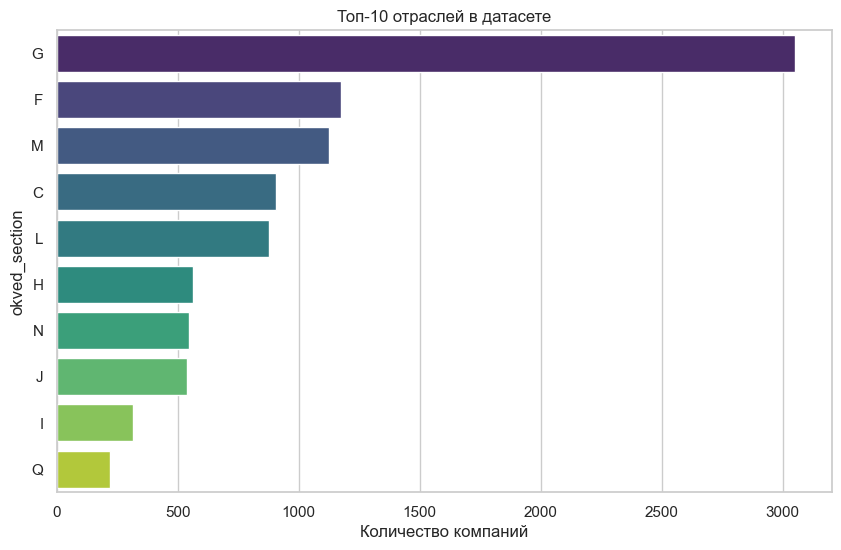

C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_11384\607347801.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.values, y=region_counts.index, palette='magma')


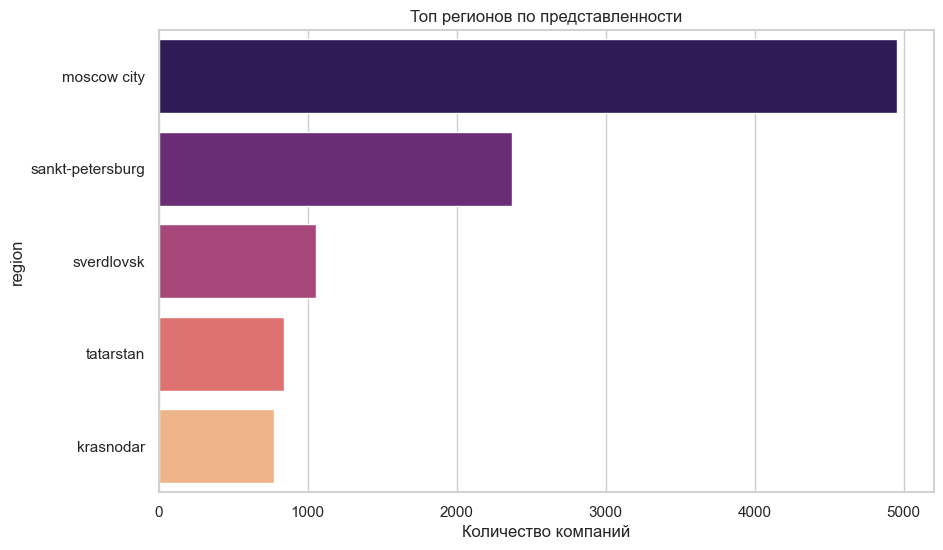

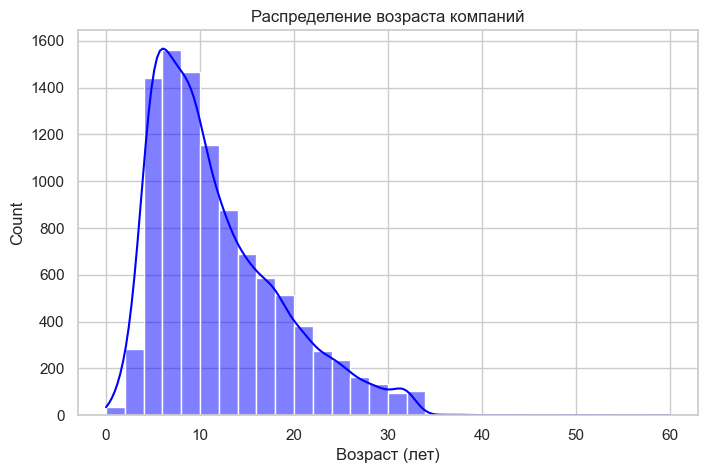

In [11]:
# Настраиваем стиль
sns.set_theme(style="whitegrid")

# 1. ТОП-10 отраслей (ОКВЭД)
plt.figure(figsize=(10, 6))
okved_counts = final_df['okved_section'].value_counts().head(10)
sns.barplot(x=okved_counts.values, y=okved_counts.index, palette='viridis')
plt.title('Топ-10 отраслей в датасете')
plt.xlabel('Количество компаний')
plt.show()

# 2. ТОП-10 регионов
plt.figure(figsize=(10, 6))
region_counts = final_df['region'].value_counts().head(10)
sns.barplot(x=region_counts.values, y=region_counts.index, palette='magma')
plt.title('Топ регионов по представленности')
plt.xlabel('Количество компаний')
plt.show()

# 3. Распределение возраста (гистограмма)
plt.figure(figsize=(8, 5))
sns.histplot(final_df['max_age'], bins=30, kde=True, color='blue')
plt.title('Распределение возраста компаний')
plt.xlabel('Возраст (лет)')
plt.show()

Вывели распределение отраслей, регионов и возрастов компаний с ограничением по региону. Расшифровка буквенных обозначений отраслей произведена при формировании json-профилей компаний.

### упаковка данных в готовый json с отдельными форматами для каждой модели

Расшифровка буквенных обозначений отраслей

In [12]:
OKVED_MAPPING = {
    "A": "Сельское хозяйство и охота",
    "B": "Добыча полезных ископаемых",
    "C": "Обрабатывающие производства",
    "D": "Энергетика и газоснабжение",
    "E": "Водоснабжение и утилизация отходов",
    "F": "Строительство",
    "G": "Торговля и ремонт автотранспорта",
    "H": "Транспортировка и хранение",
    "I": "Гостиницы и общепит",
    "J": "IT, информация и связь",
    "K": "Финансы и страхование", 
    "L": "Операции с недвижимостью",
    "M": "Профессиональная и научная деятельность",
    "N": "Административная деятельность",
    "O": "Государственное управление",
    "P": "Образование",
    "Q": "Здравоохранение и социальные услуги",
    "R": "Культура, спорт и развлечения",
    "S": "Предоставление прочих услуг",
    "T": "Деятельность домашних хозяйств",
    "U": "Экстерриториальные организации"
}

Функция формирования json-профиля компании. Основная идея - формирование json-заготовки для подачи в LLM-эксперта для генерации синтетического таргета и формирование отдельного текстового описания финансового состояния компании для модели-эмбеддера. Прокси-таргет сохранялся как ориентир для подвтерждения того, что компания на момент 2024 года еще действует и мы исследуем потенциальный риск дефолта.

In [36]:
def prepare_json(raw_json_data):
    if isinstance(raw_json_data, str):
        data = json.loads(raw_json_data)
    else:
        data = raw_json_data
        
    allowed_keys = {
        'region', 'okved_section', 'max_age', 
        'last_rev', 'last_prof', 'last_cap', 'last_debt', 'last_assets',
        'revenue_trend_pct', 'profit_trend_per_year'
    }
    
    processed_data =[]

    for company in data:
        clean_profile = {}
        for key, value in company.items():
            if pd.isna(value) or value == "": 
                continue
                
            if key in allowed_keys:
                if key == 'okved_section':
                    clean_profile[key] = OKVED_MAPPING.get(value, value)
                else:
                    if isinstance(value, float):
                        clean_profile[key] = round(value, 4)
                    else:
                        clean_profile[key] = value
                        
        if not clean_profile:
            continue
            
        json_for_llm = json.dumps(clean_profile, ensure_ascii=False, separators=(',', ':'))
        
        age = clean_profile.get('max_age', 0)
        prof = clean_profile.get('last_prof', 0)
        trend = clean_profile.get('revenue_trend_pct', 0)
        debt = clean_profile.get('last_debt', 0)
        cap = clean_profile.get('last_cap', 0)
        
        if age < 3: age_str = "молодая компания (стартап)"
        elif age > 10: age_str = "старая укоренившаяся компания"
        else: age_str = "зрелая компания"
            
        # Перевод рентабельности
        prof_str = "прибыльный бизнес" if prof > 0 else "убыточный бизнес"
            
        # Перевод тренда
        if trend > 0.1: trend_str = "активный рост выручки"
        elif trend < -0.1: trend_str = "сильное падение выручки"
        else: trend_str = "стагнирующая/стабильная выручка"
            
        # Перевод долговой нагрузки
        if cap > 0 and (debt / cap) > 1:
            debt_str = "высокая долговая нагрузка (закредитованность)"
        elif cap <= 0 and debt > 0:
            debt_str = "критический риск (отрицательный капитал при наличии долгов)"
        else:
            debt_str = "финансово устойчивая (капитал покрывает долги)"

        # Финансы в начале, география и отрасль в конце мягким текстом
        region_val = clean_profile.get('region', 'Неизвестно')
        okved_val = clean_profile.get('okved_section', 'Неизвестно')
        
        text_for_embedder = (
            f"{age_str}. {prof_str}, {trend_str}. {debt_str}. "
            f"Деятельность ведется в сфере: {okved_val}, локация: {region_val}."
        )

        processed_data.append({
            "inn": company.get("inn"),
            "proxy_target": company.get("real_default", 0),
            "text_for_embedding": text_for_embedder, # <-- Уйдет в Qwen-Embedding
            "json_for_llm": json_for_llm             # <-- Уйдет в LLM
        })
            
    return processed_data

Пример заготовки по одной компании

In [37]:
raw_data_list = final_df.to_dict(orient='records')
data_ready = prepare_json(raw_data_list)

print(f"Всего {len(data_ready)} профилей.\nПример:")
print("ИНН:", data_ready[0]['inn'])
print("Ориентировочный таргет:", data_ready[0]['proxy_target'])
print("Текст для эмбеддера:", data_ready[0]['text_for_embedding'])
print("Текст для эксперта:", data_ready[0]['json_for_llm'])

Всего 10000 профилей.
Пример:
ИНН: 278920547.0
Ориентировочный таргет: 0
Текст для эмбеддера: зрелая компания. прибыльный бизнес, активный рост выручки. финансово устойчивая (капитал покрывает долги). Деятельность ведется в сфере: Гостиницы и общепит, локация: moscow city.
Текст для эксперта: {"region":"moscow city","okved_section":"Гостиницы и общепит","max_age":8.0,"last_rev":236051.0,"last_prof":24843.0,"last_cap":15292.0,"last_debt":9703.0,"last_assets":41991.0,"revenue_trend_pct":4.7682,"profit_trend_per_year":2388.17}


Пояснения атрибутов json-профиля для LLM-эксперта внесены в системный промпт

### построение эмбеддингов компаний

Полученные текстовые профили были векторизованы с использованием локально развернутой модели Qwen/Qwen3-Embedding-0.6B, оптимизированной для задачи вычисления семантического сходства. На выходе была получена матрица эмбеддингов размерностью 10000×1024.

In [ ]:
texts_to_embed = [item['text_for_embedding'] for item in data_ready]
model = SentenceTransformer('Qwen/Qwen3-Embedding-0.6B', device='cuda')
embeddings = model.encode(texts_to_embed, batch_size=16, show_progress_bar=True)

print(f"Размерность матрицы эмбеддингов: {embeddings.shape}")

Batches: 100%|██████████| 625/625 [01:52<00:00,  5.57it/s]

Размерность матрицы эмбеддингов: (10000, 1024)


In [41]:
np.save(f'{save_path}data_ready.npy', data_ready)
np.save(f'{save_path}embeddings_new_10000.npy', embeddings)

### построение графа схожести компаний

В ходе исследования были протестированы различные алгоритмы формирования графа сходства компаний. Результат подхода с фиксированным порогом не соответствовал цели работы, так как оставлял много изолированных вершин. Выбран алгоритм kNN с гиперпараметром 6 (поиск 5 соседей по косиносному сходству). В результате образовались естественные хабы, при этом у каждой компании были соседи. Компании разбились на изолированные подграфы.

In [43]:
print("Ищем 5 ближайших соседей для каждой компании")
knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(embeddings)
distances, indices = knn.kneighbors(embeddings)

G = nx.Graph()
G.add_nodes_from(range(len(embeddings)))

print("Сшиваем граф")
for i in range(len(indices)):
    for j in indices[i][1:]: # Пропускаем индекс 0 (самого себя)
        G.add_edge(i, j)

degrees = [degree for node, degree in G.degree()]
isolates = list(nx.isolates(G))

print("\nИТОГОВЫЙ ГРАФ")
print(f"Вершин: {G.number_of_nodes()}")
print(f"Ребер: {G.number_of_edges()}")
print(f"Число изолированных вершин: {len(isolates)}")
print(f"Средняя степень вершины: {np.mean(degrees):.1f}")
print(f"Максимальная степень верины: {max(degrees)}")

Ищем 5 ближайших соседей для каждой компании
Сшиваем граф

ИТОГОВЫЙ ГРАФ
Вершин: 10000
Ребер: 42758
Число изолированных вершин: 0
Средняя степень вершины: 8.6
Максимальная степень верины: 273


In [31]:
edges_df = nx.to_pandas_edgelist(G)
edges_df.to_csv(f'{save_path}graph_edges_new_10000.csv', index=False)

### визуализация подграфа

На этом этапе пришла идея с различными входными данными для эмбеддера и ЛЛМ-эксперта. При визуализации было очевидно, что эмбеддер игнорирует числовые данные и опирается только на текстовую связку отрасль+регион. В результате смены подхода образовались подграфы со смешанными отраслями и регионами. На картинке пример - цветов закодирована отрасль.

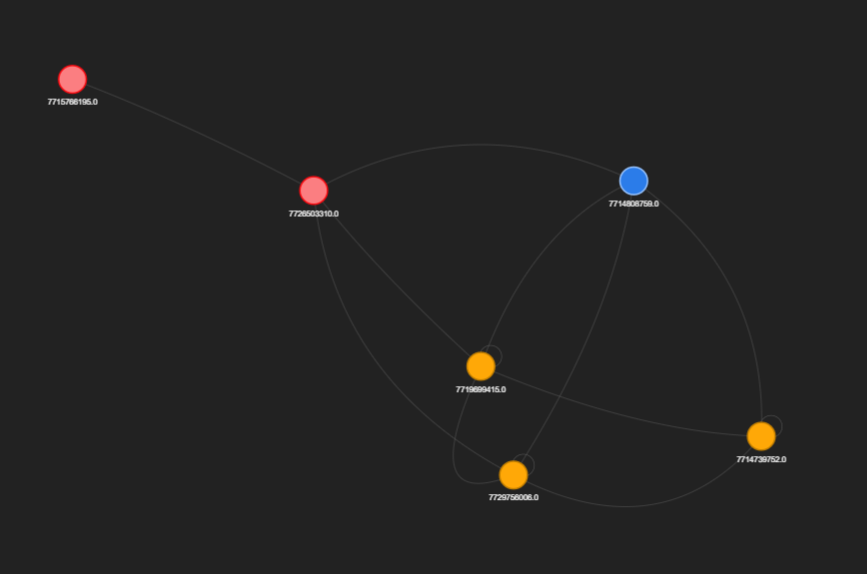

Для визуализации был отобран подграф 1200 вершин

In [ ]:
VIS_SIZE = 1200

all_nodes = list(G.nodes())
random_nodes = random.sample(all_nodes, k=min(VIS_SIZE, len(all_nodes)))

G_sub = G.subgraph(random_nodes)

net_vis = Network(notebook=True, cdn_resources='remote', height="700px", width="100%", bgcolor="#222222", font_color="white")

for node_id in G_sub.nodes():
    item = data_ready[node_id] 
    profile = json.loads(item['json_for_llm'])
    
    inn = item['inn']
    region = profile.get('region', 'Неизвестно')
    okved = profile.get('okved_section', 'Неизвестно')
    semantic_desc = item['text_for_embedding']
    
    hover_text = f"ИНН: {inn}\nРегион: {region}\nОтрасль: {okved}\n\n\n{semantic_desc}"
    net_vis.add_node(int(node_id), label=str(inn), title=hover_text, group=okved)

for u, v in G_sub.edges():
    net_vis.add_edge(int(u), int(v), color="#555555")

net_vis.barnes_hut(gravity=-5000, central_gravity=0.1, spring_length=200)
net_vis.show(f"{save_path}graph_random_new_{VIS_SIZE}.html")

./saved_1/graph_random_new_1200.html


Скриншот подграфа. Видим кластеры. Вариант визуализации (в html) дает возможность вывести информацию о компании при наведении, а также подвигать вершины графа.

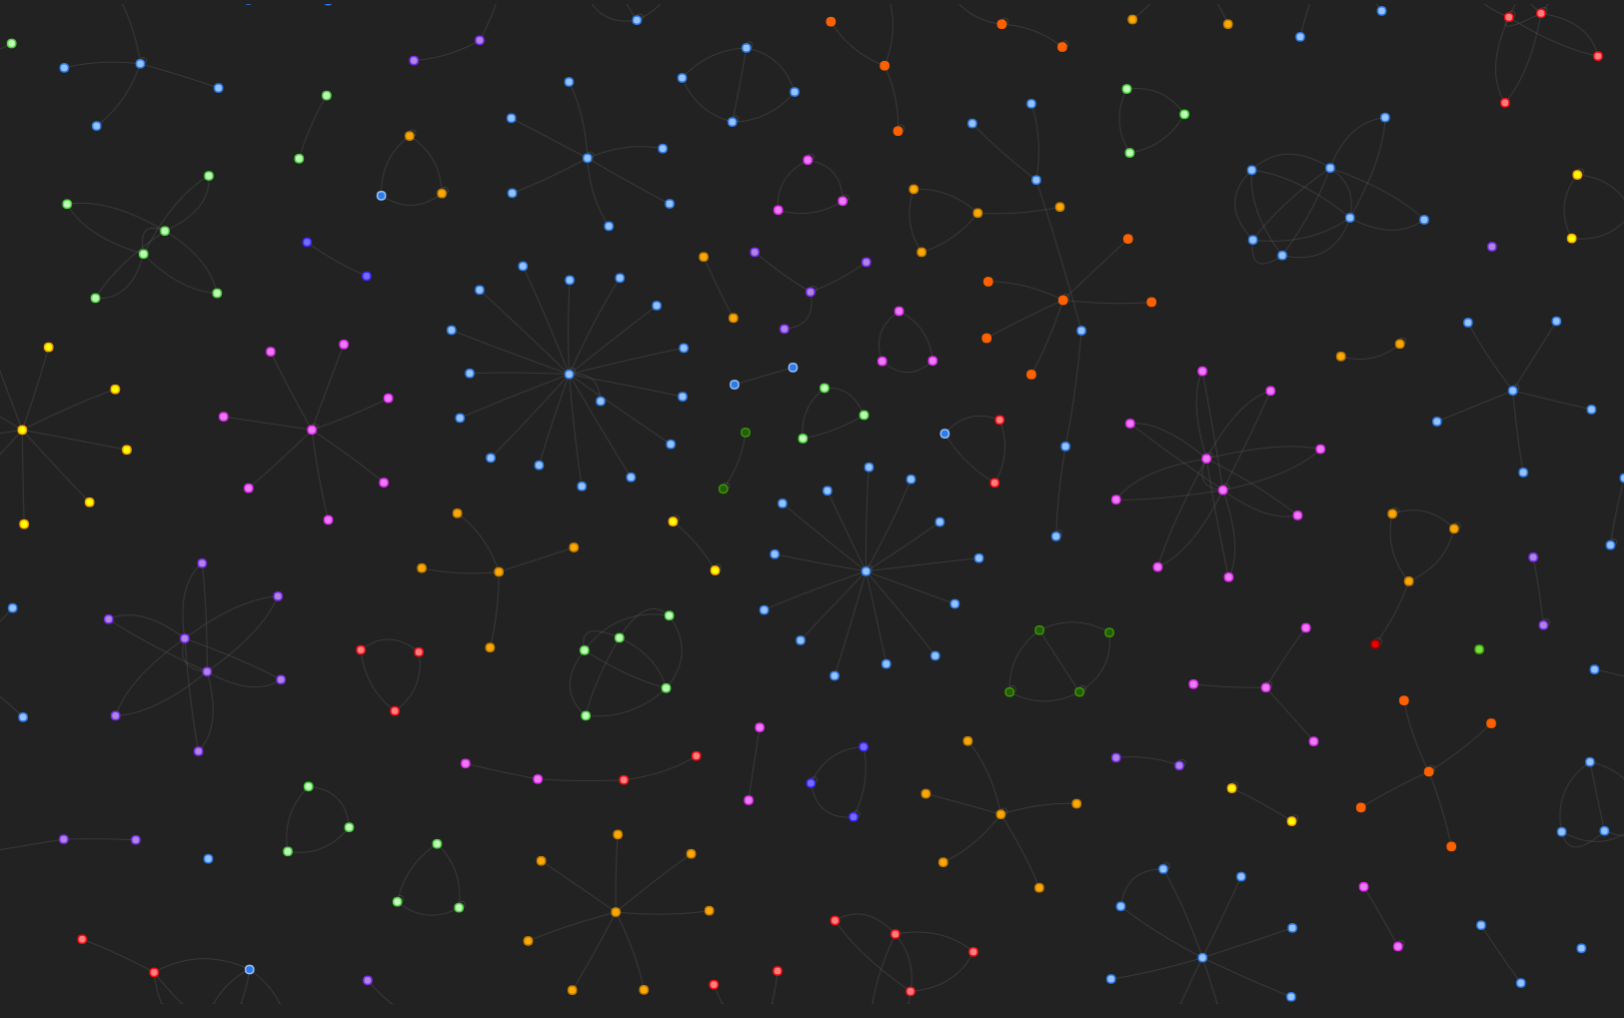

### аналитика по графу

Анализ графа после неудачных попыток с подходов четкого порога показал, что у нас появились желанные мультиотраслевые и мультирегиональные кластеры. Также был проведен анализ самого большого подграфа.

In [ ]:
components = list(nx.connected_components(G))
print(f"Найдено изолированных подграфов (кластеров): {len(components)}")

cluster_stats =[]

for i, comp in enumerate(components):
    regions = set()
    okveds = set()
    
    for node_id in comp:
        item = data_ready[node_id]
        profile = json.loads(item['json_for_llm'])
        regions.add(profile.get('region', 'Неизвестно'))
        okveds.add(profile.get('okved_section', 'Неизвестно'))
        
    cluster_stats.append({
        'cluster_id': i + 1,
        'size': len(comp),
        'unique_regions': len(regions),
        'unique_okveds': len(okveds)
    })

df_clusters = pd.DataFrame(cluster_stats)

df_valid = df_clusters[df_clusters['size'] >= 5]

print("\nСТАТИСТИКА ИЗОЛИРОВАННЫМ ПОДГРАФАМ:")
print(f"Значимых подграфов: {len(df_valid)}")
print(f"Средний размер: {df_valid['size'].mean():.1f} компаний")
print(f"Самый большой подграф: {df_valid['size'].max()} компаний")

cross_regional = len(df_valid[df_valid['unique_regions'] > 1])
cross_industry = len(df_valid[df_valid['unique_okveds'] > 1])
full_mix = len(df_valid[(df_valid['unique_regions'] > 1) & (df_valid['unique_okveds'] > 1)])

print(f"\nМежрегиональных (внутри одного куска есть разные регионы): {cross_regional} из {len(df_valid)} ({cross_regional/len(df_valid)*100:.1f}%)")
print(f"Межотраслевых (внутри одного куска есть разные ОКВЭД): {cross_industry} из {len(df_valid)} ({cross_industry/len(df_valid)*100:.1f}%)")
print(f"Полный микс (и регионы, и отрасли): {full_mix} ({full_mix/len(df_valid)*100:.1f}%)")

Найдено изолированных подграфов (кластеров): 257

СТАТИСТИКА ИЗОЛИРОВАННЫМ ПОДГРАФАМ:
Значимых подграфов: 257
Средний размер: 38.9 компаний
Самый большой подграф: 3219 компаний

Межрегиональных (внутри одного куска есть разные регионы): 17 из 257 (6.6%)
Межотраслевых (внутри одного куска есть разные ОКВЭД): 24 из 257 (9.3%)
Полный микс (и регионы, и отрасли): 2 (0.8%)


In [ ]:
components = list(nx.connected_components(G))
giant_component = max(components, key=len)

print(f"Размер самого большого кластера: {len(giant_component)} компаний.")

giant_data =[]
for node_id in giant_component:
    item = data_ready[node_id]
    profile = json.loads(item['json_for_llm'])
    giant_data.append(profile)

df_giant = pd.DataFrame(giant_data)

print("\nАНАЛИТИЧЕСКИЙ ПРОФИЛЬ БОЛЬШОГО КЛАСТЕРА")

print("\nРегионы:")
print(df_giant['region'].value_counts().head(5).to_string())

print("\nТоп-5 отраслей (ОКВЭД):")
print(df_giant['okved_section'].value_counts().head(5).to_string())

print("\nФИНАНСОВЫЙ ПОРТРЕТ (Медианные значения):")
print(f"Возраст компании:     {df_giant['max_age'].median():.1f} лет")
print(f"Последняя выручка:    {df_giant['last_rev'].median():,.0f} тыс. руб.")
print(f"Последняя прибыль:    {df_giant['last_prof'].median():,.0f} тыс. руб.")
print(f"Размер долга:         {df_giant['last_debt'].median():,.0f} тыс. руб.")
print(f"Тренд выручки (%):    {df_giant['revenue_trend_pct'].median() * 100:.1f}%")

bankrupts_count = sum([data_ready[node_id].get('proxy_target', 0) for node_id in giant_component])
bankrupt_rate = (bankrupts_count / len(giant_component)) * 100
print(f"\nДоля ориентировочных дефолтов в кластере: {bankrupt_rate:.2f}%")

Размер самого большого кластера: 3219 компаний.

АНАЛИТИЧЕСКИЙ ПРОФИЛЬ БОЛЬШОГО КЛАСТЕРА

Регионы:
region
moscow city         1154
sankt-petersburg     824
tatarstan            443
sverdlovsk           427
krasnodar            371

Топ-5 отраслей (ОКВЭД):
okved_section
Обрабатывающие производства                673
Профессиональная и научная деятельность    369
Строительство                              312
Гостиницы и общепит                        264
Административная деятельность              229

ФИНАНСОВЫЙ ПОРТРЕТ (Медианные значения):
Возраст компании:     10.0 лет
Последняя выручка:    4,918 тыс. руб.
Последняя прибыль:    19 тыс. руб.
Размер долга:         2,260 тыс. руб.
Тренд выручки (%):    26.7%

Доля ориентировочных дефолтов в кластере: 0.00%


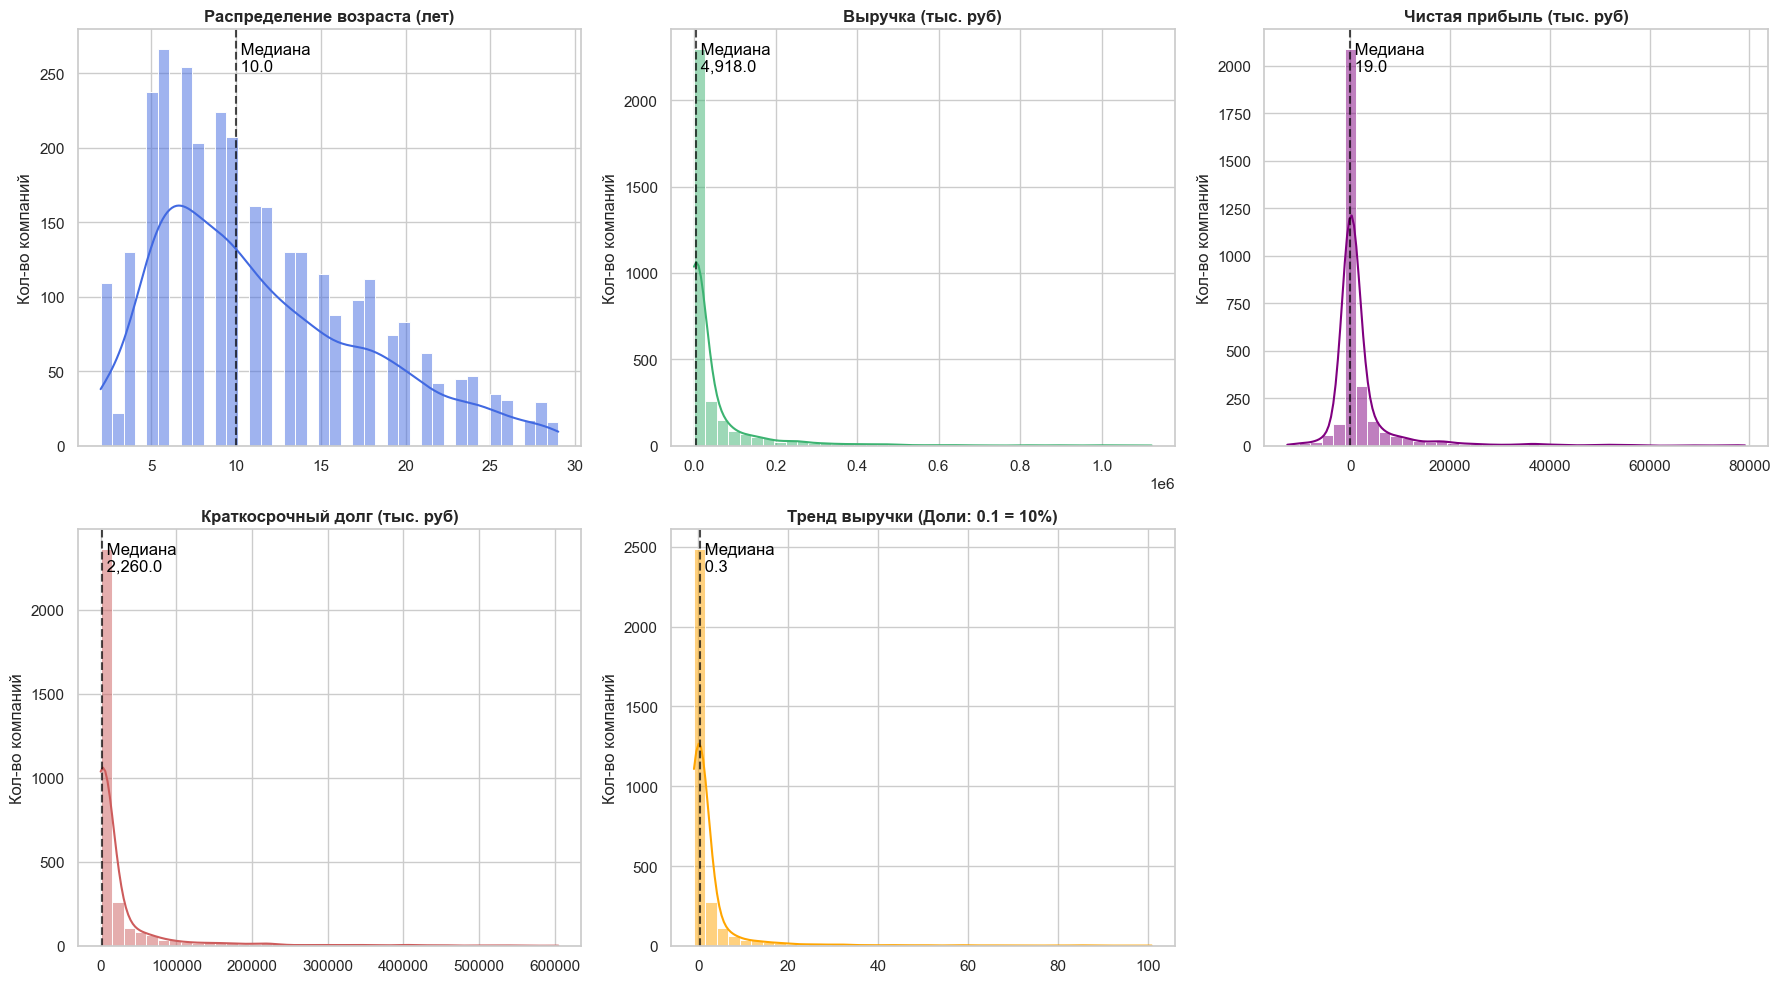

Оценка единообразия компаний внутри кластера:
• Возраст: от 7.0 до 16.0 (Медиана: 10.0)
• Выручка: от 0.0 до 38,687.5 (Медиана: 4,918.0)
• Прибыль: от 0.0 до 1,435.0 (Медиана: 19.0)
• Тренд выручки: от -0.6 до 1.2 (Медиана: 0.3)


In [ ]:
sns.set_theme(style="whitegrid")

def plot_distribution(data, column, ax, title, color):
    lower_bound = data[column].quantile(0.02)
    upper_bound = data[column].quantile(0.98)
    
    subset = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    
    sns.histplot(subset[column], bins=40, kde=True, ax=ax, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Кол-во компаний')
    
    median_val = data[column].median()
    ax.axvline(median_val, color='black', linestyle='--', alpha=0.7)
    ax.text(median_val, ax.get_ylim()[1]*0.9, f' Медиана\n {median_val:,.1f}', color='black')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_distribution(df_giant, 'max_age', axes[0,0], 'Распределение возраста (лет)', 'royalblue')

plot_distribution(df_giant, 'last_rev', axes[0,1], 'Выручка (тыс. руб)', 'mediumseagreen')

plot_distribution(df_giant, 'last_prof', axes[0,2], 'Чистая прибыль (тыс. руб)', 'purple')

plot_distribution(df_giant, 'last_debt', axes[1,0], 'Краткосрочный долг (тыс. руб)', 'indianred')

plot_distribution(df_giant, 'revenue_trend_pct', axes[1,1], 'Тренд выручки (Доли: 0.1 = 10%)', 'orange')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

print("Оценка единообразия компаний внутри кластера:")
for col, name in zip(['max_age', 'last_rev', 'last_prof', 'revenue_trend_pct'],['Возраст', 'Выручка', 'Прибыль', 'Тренд выручки']):
    q25 = df_giant[col].quantile(0.25)
    q75 = df_giant[col].quantile(0.75)
    print(f"• {name}: от {q25:,.1f} до {q75:,.1f} (Медиана: {df_giant[col].median():,.1f})")

Видим, что подграф содержит профили стагнирующих низкоприбыльных компаний из всех регионов и отраслей. Еще одно свидетельство того, что теперь эмбеддер ориентируется не только на регионы и отрасли, но еще и на финансовую картину.

### оценка компаний ЛЛМ-экспертом (генерация синтетического таргета)

Тестовый запуск на первых 1000 компаний из датасета (просто проверка работы локальной модели). Компании в датасете отсортированы по ИНН (прямо зависит от возраста), поэтому для реальной первыичной аналитики использован sample.

In [13]:
url = "http://127.0.0.1:1234/v1/chat/completions"

system_prompt = """Ты senior-андеррайтер корпоративного бизнеса. Твоя задача — проанализировать финансовые показатели, тренды и метаданные компании, чтобы предсказать риск её кредитного дефолта.
0 - компания выживет и выплатит кредит.
1 - высокий риск банкротства/дефолта.

Опирайся ИСКЛЮЧИТЕЛЬНО на свои внутренние знания макроэкономики, корпоративных финансов и отраслевой специфики. 
Сформулируй неочевидную бизнес-гипотезу: объясни, почему именно такая комбинация факторов ведет к твоему прогнозу.

Твой инструментарий:
- revenue_trend_pct: рост/падение выручки за период. Значение > 0 означает рост.
- last_prof: финансовый результат (чистая прибыль/убыток).
- last_debt: текущие краткосрочные обязательства.
- last_cap: собственный капитал компании.

Выведи финальный ответ СТРОГО в формате JSON:
{"default": 1, "reason": "Твоя гипотеза"}
"""

def generate_target_direct(company_profile_text):
    payload = {
        "model": "qwen/qwen3-8b",
        "messages":[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Оцени компанию: {company_profile_text}"}
        ],
        "temperature": 0.1
    }
    
    try:
        response = requests.post(url, json=payload, timeout=60)
        
        if response.status_code != 200:
            return {"default": None, "reason": f"Ошибка {response.status_code}"}
            
        content = response.json()['choices'][0]['message']['content']
        
        # Вырезаем мысли модели (от <think> до </think>)
        content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
        
        # Очищаем от Markdown
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0].strip()
            
        return json.loads(content)
        
    except Exception as e:
        return {"default": None, "reason": f"Ошибка скрипта: {e}"}

sample_for_llm = data_ready[:1000]
results_full =[]
save_interval = 5

print("Начало генерации таргетов\n")

for i, item in enumerate(tqdm(sample_for_llm), 1):
    profile = item['text_for_embedding']
    inn = item['inn']
    
    llm_answer = generate_target_direct(profile)
    
    results_full.append({
        "inn": inn,
        "profile": profile,
        "proxy_target": item.get('proxy_target', 0),
        "synthetic_default": llm_answer.get("default"),
        "llm_reason": llm_answer.get("reason")
    })

    if i % save_interval == 0:
        pd.DataFrame(results_full).to_csv(f"{save_path}backup_synthetic_targets_1000.csv", index=False)

df_targets_full = pd.DataFrame(results_full)
display(df_targets_full)

df_targets_full.to_csv(f"{save_path}synthetic_targets_full_1000.csv", index=False)

Начало генерации таргетов



100%|██████████| 1000/1000 [3:21:37<00:00, 12.10s/it] 


,inn,profile,proxy_target,synthetic_default,llm_reason
0,2.789205e+08,"зрелая компания. прибыльный бизнес, активный р...",0,1.0,Несмотря на активный рост выручки и финансовую...
1,8.140713e+08,старая укоренившаяся компания. прибыльный бизн...,0,1.0,Активный рост выручки в условиях устаревшей ин...
2,8.160112e+08,старая укоренившаяся компания. прибыльный бизн...,0,1.0,"Несмотря на прибыльный бизнес и рост выручки, ..."
3,1.001270e+09,старая укоренившаяся компания. прибыльный бизн...,0,1.0,"Компания, несмотря на прибыльный бизнес, сталк..."
4,1.101055e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,1.0,Компания находится в зрелой стадии с убыточным...
...,...,...,...,...,...
995,2.308268e+09,"зрелая компания. убыточный бизнес, стагнирующа...",0,1.0,Несмотря на финансовую устойчивость (капитал п...
996,2.308268e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,1.0,Комбинация убыточного бизнеса и падения выручк...
997,2.308269e+09,"зрелая компания. убыточный бизнес, стагнирующа...",0,1.0,"Компания находится в гостиничной сфере, где вы..."
998,2.308270e+09,"зрелая компания. убыточный бизнес, стагнирующа...",0,1.0,Убыточный зрелый бизнес с стагнирующей выручко...


C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_27424\2491747023.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='synthetic_default', palette='Set2', ax=axes[0])


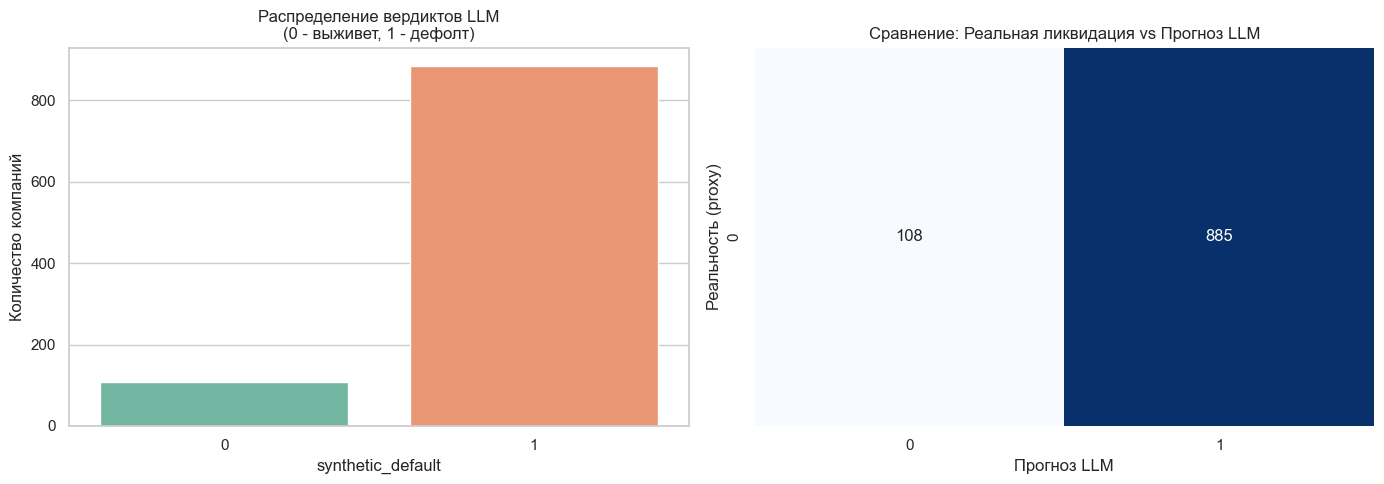

In [ ]:
df_clean = df_targets_full.dropna(subset=['synthetic_default']).copy()
df_clean['synthetic_default'] = df_clean['synthetic_default'].astype(int)
df_clean['proxy_target'] = df_clean['proxy_target'].astype(int)

crosstab_count = pd.crosstab(df_clean['proxy_target'], df_clean['synthetic_default'], 
                             rownames=['Реальность (proxy)'], colnames=['Прогноз LLM'])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='synthetic_default', palette='Set2', ax=axes[0])
axes[0].set_title('Распределение вердиктов LLM\n(0 - выживет, 1 - дефолт)', fontsize=12)
axes[0].set_ylabel('Количество компаний')

sns.heatmap(crosstab_count, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Сравнение: Реальная ликвидация vs Прогноз LLM', fontsize=12)

plt.tight_layout()
plt.show()

Видим, что на тестовом запуске модель показала себя как очень строгого эксперта. Смотрим на репрезентативной подвыборке и убеждаемся, что это не специфика старых компаний.

In [ ]:
url = "http://127.0.0.1:1234/v1/chat/completions"

system_prompt = """Ты senior-андеррайтер корпоративного бизнеса. Твоя задача — проанализировать финансовые показатели, тренды и метаданные компании, чтобы предсказать риск её кредитного дефолта.
0 - компания выживет и выплатит кредит.
1 - высокий риск банкротства/дефолта.

Опирайся ИСКЛЮЧИТЕЛЬНО на свои внутренние знания макроэкономики, корпоративных финансов и отраслевой специфики. 
Сформулируй неочевидную бизнес-гипотезу: объясни, почему именно такая комбинация факторов ведет к твоему прогнозу.

Твой инструментарий:
- revenue_trend_pct: рост/падение выручки за период. Значение > 0 означает рост.
- last_prof: финансовый результат (чистая прибыль/убыток).
- last_debt: текущие краткосрочные обязательства.
- last_cap: собственный капитал компании.

Выведи финальный ответ СТРОГО в формате JSON:
{"default": 1, "reason": "Твоя гипотеза"}
"""

def generate_target_direct(company_profile_text):
    payload = {
        "model": "qwen/qwen3-8b",
        "messages":[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Оцени компанию: {company_profile_text}"}
        ],
        "temperature": 0.1
    }
    
    try:
        response = requests.post(url, json=payload, timeout=60)
        
        if response.status_code != 200:
            return {"default": None, "reason": f"Ошибка {response.status_code}"}
            
        content = response.json()['choices'][0]['message']['content']
        
        content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
        
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0].strip()
            
        return json.loads(content)
        
    except Exception as e:
        return {"default": None, "reason": f"Ошибка скрипта: {e}"}

backup_filename = f"{save_path}backup_synthetic_targets_re_1000.csv"
results_full = []
processed_inns = set()

if os.path.exists(backup_filename):
    print("Найден бэкап, загружаем предыдущие результаты...")
    existing_df = pd.read_csv(backup_filename)
    results_full = existing_df.to_dict('records')
    processed_inns = set(str(x) for x in existing_df['inn'])
    print(f"Уже обработано: {len(processed_inns)} компаний.")

TARGET_COUNT = 1000
needed_count = TARGET_COUNT - len(processed_inns)

if needed_count > 0:
    print(f"Осталось доделать: {needed_count} компаний.")
    available_data = [item for item in data_ready if str(item['inn']) not in processed_inns]
    sample_for_llm = random.sample(available_data, needed_count)
else:
    print("Файл уже содержит 1000 или более записей! Догенерация не требуется.")
    sample_for_llm = []

save_interval = 10

if len(sample_for_llm) > 0:
    print("\nНачало генерации таргетов")
    
    for i, item in enumerate(tqdm(sample_for_llm), 1):
        profile = item['text_for_embedding']
        inn = item['inn']
        
        llm_answer = generate_target_direct(profile)
        
        results_full.append({
            "inn": inn,
            "profile": profile,
            "proxy_target": item.get('proxy_target', 0),
            "synthetic_default": llm_answer.get("default"),
            "llm_reason": llm_answer.get("reason")
        })

        if i % save_interval == 0 or i == len(sample_for_llm):
            pd.DataFrame(results_full).to_csv(backup_filename, index=False)

df_targets_full = pd.DataFrame(results_full)
display(df_targets_full)

df_targets_full.to_csv(f"{save_path}synthetic_targets_re_1000.csv", index=False)

Найден бэкап, загружаем предыдущие результаты...
Уже обработано: 610 компаний.
Осталось доделать: 390 компаний.

Начало генерации таргетов


100%|██████████| 390/390 [1:19:31<00:00, 12.23s/it]


,inn,profile,proxy_target,synthetic_default,llm_reason
0,2.353023e+09,старая укоренившаяся компания. прибыльный бизн...,0,0.0,Несмотря на рост выручки и финансовую устойчив...
1,5.018081e+09,старая укоренившаяся компания. убыточный бизне...,0,1.0,Высокая долговая нагрузка в строительной сфере...
2,7.811715e+09,"зрелая компания. прибыльный бизнес, активный р...",0,NaN,Ошибка скрипта: Extra data: line 1 column 650 ...
3,7.719487e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,1.0,"Компания, несмотря на финансовую устойчивость ..."
4,6.672349e+09,старая укоренившаяся компания. прибыльный бизн...,0,1.0,Сильное падение выручки в условиях прибыльного...
...,...,...,...,...,...
995,1.655413e+09,"зрелая компания. прибыльный бизнес, активный р...",0,1.0,Высокая долговая нагрузка в сочетании с активн...
996,7.718183e+09,старая укоренившаяся компания. прибыльный бизн...,0,0.0,Активный рост выручки в условиях высокой конку...
997,7.727504e+09,старая укоренившаяся компания. прибыльный бизн...,0,1.0,Несмотря на финансовую устойчивость (капитал п...
998,9.718056e+09,"зрелая компания. прибыльный бизнес, активный р...",0,0.0,Активный рост выручки в условиях высокой конку...


C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_13508\1825351664.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='synthetic_default', palette='Set2', ax=axes[0])


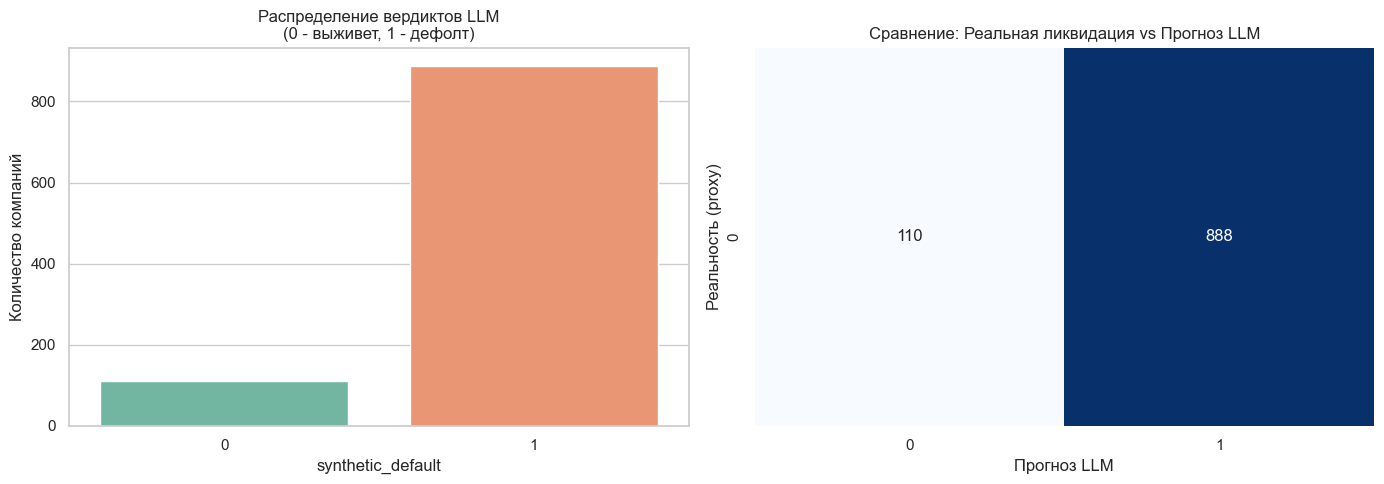

In [ ]:
df_clean = df_targets_full.dropna(subset=['synthetic_default']).copy()
df_clean['synthetic_default'] = df_clean['synthetic_default'].astype(int)
df_clean['proxy_target'] = df_clean['proxy_target'].astype(int)

crosstab_count = pd.crosstab(df_clean['proxy_target'], df_clean['synthetic_default'], 
                             rownames=['Реальность (proxy)'], colnames=['Прогноз LLM'])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='synthetic_default', palette='Set2', ax=axes[0])
axes[0].set_title('Распределение вердиктов LLM\n(0 - выживет, 1 - дефолт)', fontsize=12)
axes[0].set_ylabel('Количество компаний')

sns.heatmap(crosstab_count, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Сравнение: Реальная ликвидация vs Прогноз LLM', fontsize=12)

plt.tight_layout()
plt.show()

Опасения подтвердились: ЛЛМ-эксперт очень критичен. При генерации помимо синтетического таргета мы получали краткий комментарий-обоснование от LLM. Полученный список профилей компаний с вердиктом эксперта и комментарием отправляем на анализ в Gemini 3.1 Pro. Ниже представлен промпт для формирования гипотез по данным, которые мы далее резюмируем и включаем в обновленный промпт для LLM-эксперта-разметчика.

### промпт для выделения гипотез по первичной разметке

в начале сообщения опиши, получил ли ты файл и можешь ли его прочитать (скопируй первые две строки, чтобы я убедилась, что формат не сломался)

 Во вложенном файле находятся результаты скоринга выборки компаний. Разметка проведена AI-агентом на основе финансовых трендов и семантики (колонки `synthetic_default` и `llm_reason`).
Обрати внимание: `proxy_target` = 0 у всех компаний означает, что на момент сбора данных они существуют, но AI-агент пометил многие из них как потенциально дефолтные (`synthetic_default` = 1), увидев скрытые уязвимости в их экономике.

Твоя задача: проанализировать колонку `llm_reason` и выявить **5 неочевидных макроэкономических и отраслевых закономерностей (гипотез)**, которые приводят к скрытому риску дефолта. Они должны быть легко проверяемыми в открытых источниках и легко формулируемыми.

Оформи ответ в виде списка 5 гипотез по формату:
1. Краткая формулировка гипотезы
2. На основании каких закономерностей из файла был сделан вывод
3. Подтверждается ли гипотеза на основе твоей экспертизы и общедоступных данных

### ответ ЛЛМ (10 гипотез по разметке от gemini 3.1 pro)

#### Подтвержденные гипотезы

#### 1. "Иллюзия роста на госзаказах": ловушка субсидий в науке, ИТ и здравоохранении
*   **Краткая формулировка гипотезы:** Компании из наукоемких, ИТ и социальных сфер, показывающие активный рост выручки, находятся в зоне скрытого дефолта из-за тотальной зависимости от региональных бюджетов и субсидий, которые подвержены внезапным сокращениям.
*   **На основании каких закономерностей из файла сделан вывод:** Агент регулярно помечает ИТ, научные учреждения и клиники (особенно в Татарстане и Краснодаре) как дефолтные, несмотря на "активный рост выручки" и "финансовую устойчивость". Обоснование агента: рост связан с временными госпрограммами, а не с рыночным спросом. При малейшем секвестре бюджета или перераспределении средств эти компании лишаются денежного потока, но остаются с возросшими издержками на инфраструктуру и R&D.
*   **Подтверждается ли гипотеза:** Да. По данным открытых источников, бюджетные расходы регионов РФ сейчас жестко приоритизируются. Отрасли, зависящие от грантов, ФОМС или нацпроектов, сталкиваются с задержками выплат или отменой тендеров. Выручка на бумаге есть (акты подписаны), но реальный денежный поток (cash flow) прерывается, что ведет к кассовым разрывам.

#### 2. "Рост как катализатор банкротства": эффект overtrading в строительстве и логистике
*   **Краткая формулировка гипотезы:** Для фондоемких отраслей (строительство, транспорт) на фоне жесткой монетарной политики сам факт "активного роста выручки" при наличии долговой нагрузки становится главной причиной дефолта из-за неконтролируемого кассового разрыва.
*   **На основании каких закономерностей из файла сделан вывод:** В файле много кейсов строительных и логистических компаний с прибыльным бизнесом и растущей выручкой, но с отметкой о закредитованности. Агент делает вывод: чтобы обеспечивать рост выручки, компании вынуждены брать всё больше коротких кредитов на оборотные средства. В условиях задержек оплат от заказчиков рост выручки лишь быстрее загоняет компанию в долговую яму.
*   **Подтверждается ли гипотеза:** Абсолютно подтверждается. В финансовом анализе это явление называется *Overtrading* (переторговка). В условиях высокой ключевой ставки Банка России обслуживание нового долга для финансирования новых контрактов съедает всю рентабельность. Строители, наращивающие объемы сегодня, кредитуются под заградительные проценты, и малейшая задержка от заказчика убивает бизнес.

#### 3. Скрытый кризис рентабельности автосервисов из-за слома цепочек поставок
*   **Краткая формулировка гипотезы:** Сектор "Торговля и ремонт автотранспорта", демонстрирующий финансовую стабильность, скрыто деградирует из-за инфляции запчастей, старения автопарка и изменения потребительского поведения.
*   **На основании каких закономерностей из файла сделан вывод:** Агент методично бракует автосервисы в Краснодаре, Свердловске и Татарстане даже при стабильной выручке. Причина: выручка держится или растет исключительно за счет инфляции (роста чека на запчасти), в то время как маржинальность катастрофически падает. Также агент упоминает угрозу со стороны каршеринга, лизинга и перехода на новые виды авто (электромобили).
*   **Подтверждается ли гипотеза:** Да. Рынок авторемонта в РФ переживает кризис из-за параллельного импорта (рост себестоимости деталей на 30-50%). Клиенты переходят на экономичный ремонт (чинят только критичное). Внешне выручка СТО растет из-за удорожания чека, но прибыль падает. Это легко проверяется по открытой аналитике рынка автомаркета (например, отчеты "Автостат").

#### 4. "Сырьевое домино": уязвимость сферы услуг и недвижимости к B2B-циклам
*   **Краткая формулировка гипотезы:** В регионах с высокой концентрацией промышленности и добычи (Татарстан, Краснодар) благополучие секторов недвижимости, HoReCa и "прочих услуг" является производной от доходов базовых отраслей; они уйдут в дефолт первыми при падении сырьевых рынков.
*   **На основании каких закономерностей из файла сделан вывод:** ИИ-агент часто отмечает, что рост выручки в операциях с недвижимостью или гостиничном бизнесе Татарстана обманчив. Он аргументирует это тем, что спрос в этих секторах искусственно поддерживается доходами от нефтегазовой отрасли. Если сырьевой сектор стагнирует, B2B-спрос (корпоративные мероприятия, аренда офисов, командировки) схлопывается мгновенно, оставляя сервисные компании с неликвидными активами и долгами.
*   **Подтверждается ли гипотеза:** Подтверждается. Экономика сырьевых регионов работает по принципу мультипликатора: 1 рубль, заработанный в добыче, генерирует 3-4 рубля в сфере услуг. Открытая макроэкономическая статистика показывает, что падение индексов промышленного производства в регионе с временным лагом в 3-6 месяцев ведет к росту вакантных площадей в коммерческой недвижимости и падению загрузки гостиниц.

#### 5. "Парадокс отрицательного капитала": зомби-компании в ожидании макрошока
*   **Краткая формулировка гипотезы:** Существует пласт зрелых компаний, которые генерируют чистую прибыль и рост выручки, но живут с отрицательным собственным капиталом (накопленные прошлые убытки превышают активы). Любой внешний макроэкономический шок для них фатален.
*   **На основании каких закономерностей из файла сделан вывод:** В датасете регулярно встречается шаблон: `прибыльный бизнес, активный рост выручки. критический риск (отрицательный капитал при наличии долгов)`. ИИ делает вывод, что эти компании существуют только за счет постоянного рефинансирования. Позитивная текущая прибыль не способна перекрыть "дыру" в балансе. Они не имеют никакой «подушки безопасности».
*   **Подтверждается ли гипотеза:** Подтверждается. В экономике такие компании часто называют "зомби". Пока кредиты дешевы или выручка растет, они обслуживают текущий долг. Однако в условиях ужесточения риск-метрик банков (базельские стандарты, резервирование ЦБ) рефинансировать долг с отрицательным капиталом становится невозможно. Проверка открытых данных Федресурса по банкротствам показывает, что большинство внезапных крахов внешне "активных" компаний связано именно с историческим дефицитом собственного капитала.


#### Опровергнутые гипотезы

#### 1. "Электромобили и каршеринг убивают региональные автосервисы"
*   **Краткая формулировка гипотезы:** Региональные СТО (в Татарстане, Свердловской области и Краснодаре) находятся под угрозой массовых дефолтов из-за перехода населения на электромобили, онлайн-сервисы и каршеринг.
*   **На основании каких закономерностей из файла сделан вывод:** Агент многократно объясняет падение выручки автосервисов фразами: *"снижение спроса на ремонт из-за перехода населения к более дешёвым альтернативам (лизингу, каршерингу)"* или *"смещение клиентов... переход на электромобили"*. 
*   **Почему гипотеза не подтверждается:** Это классическая ИИ-галлюцинация, переносящая реалии Калифорнии или Норвегии на регионы РФ. По данным «Автостата», доля электромобилей в автопарке России составляет менее 0,5%, а каршеринг развит только в крупнейших мегаполисах (и эти машины тоже нужно чинить). В реальности средний возраст легкового автомобиля в РФ превысил 15 лет. Стареющий автопарк гарантирует независимым автосервисам колоссальный и стабильный спрос на годы вперед.

#### 2. "Нефтегазовый Краснодар": фантомная сырьевая зависимость Юга
*   **Краткая формулировка гипотезы:** Рынок недвижимости и услуг Краснодарского края рухнет из-за высокой зависимости региона от нефтегазовой отрасли и цен на нефть.
*   **На основании каких закономерностей из файла сделан вывод:** Описывая компании из Краснодара, ИИ-агент переносит на них паттерны сырьевых регионов (как у Татарстана) и пишет: *"рынок недвижимости в Краснодаре демонстрирует спад... зависимость от нефтяной экономики приводит к сезонным колебаниям"*.
*   **Почему гипотеза не подтверждается:** Краснодарский край (Кубань) не является нефтегазовым регионом. Драйверы экономики Юга России — это агропромышленный комплекс, туризм, строительство и логистика (порты Черного и Азовского морей). Спрос на недвижимость там диктуется мощной внутренней миграцией (переезд россиян на Юг) и федеральными инвестициями в курорты, а не котировками барреля нефти.

#### 3. "Внезапный отказ от воды": кризис спроса в сфере ЖКХ
*   **Краткая формулировка гипотезы:** Компании в сфере водоснабжения и утилизации отходов могут уйти в дефолт из-за резкого снижения объемов потребления воды населением и сезонных спадов.
*   **На основании каких закономерностей из файла сделан вывод:** Агент анализирует отрасль "Водоснабжение и утилизация отходов" и заявляет: *"сильное падение выручки... может быть связано с сезонными колебаниями спроса или снижением объемов потребления воды"*, что приведет к банкротству.
*   **Почему гипотеза не подтверждается:** ЖКХ — это естественные монополии с абсолютно неэластичным спросом. Люди и предприятия не могут "сезонно" перестать пить воду или производить мусор в объемах, способных обанкротить отрасль. Если у водоканала падает выручка, это связано исключительно с тарифным регулированием, долгами управляющих компаний или муниципального бюджета, но никак не с добровольным "снижением спроса" потребителей.

#### 4. "Зеленая угроза": экологические ограничения губят сельское хозяйство
*   **Краткая формулировка гипотезы:** Аграрный сектор подвержен высокому риску дефолта из-за ужесточения экологических стандартов и запретов на пестициды.
*   **На основании каких закономерностей из файла сделан вывод:** Агент аргументирует риски для отрасли "Сельское хозяйство и охота" (например, в Татарстане) так: *"уязвимость к ценовым колебаниям и экологическим ограничениям (например, введение запрета на пестициды) может вызвать дефолт"*.
*   **Почему гипотеза не подтверждается:** В текущих реалиях ESG-повестка и строгие экологические ограничения в российском АПК поставлены на паузу. Главный приоритет государства — продовольственная безопасность, импортозамещение и максимизация урожайности. Никаких внезапных "запретов на пестициды", способных обрушить отрасль, не вводится. Наоборот, государство субсидирует закупки удобрений и агрохимии.

#### 5. "Географическая изоляция IT": локальный рынок как приговор
*   **Краткая формулировка гипотезы:** Региональные IT-компании обречены на дефолт при падении местной экономики, так как они ограничены спросом исключительно внутри своего региона.
*   **На основании каких закономерностей из файла сделан вывод:** Оценивая IT-сектор Татарстана и Краснодара, ИИ-агент пишет: *"высокая зависимость от локального рынка (ограниченный доступ к международным клиентам) и уязвимость к технологическим сдвигам... приведут к дефициту ликвидности"*.
*   **Почему гипотеза не подтверждается:** IT — самая экстерриториальная отрасль экономики. Региональная прописка (особенно в Татарстане, где находится федеральный ИТ-хаб Иннополис) дает компаниям налоговые льготы, но их клиенты находятся по всей России (Москва, СПб) или за рубежом. Региональная IT-компания почти никогда не работает только на местный рынок, поэтому локальные экономические спады (внутри одного субъекта РФ) не ведут к дефолту таких предприятий.

### Анализ противоречий в гипотезах

#### Разбор главного вопроса: Парадокс регионального IT и Науки
**Противоречат ли друг другу риск отмены субсидий (True-1) и независимость от локального рынка (False-5)?**
Нет, не противоречат. Они описывают разную природу денег:
*   **Опровергнутая гипотеза (False-5)** говорит о коммерческом спросе (B2B/B2C). Если в Татарстане или Краснодаре закрываются местные кафе и торговые центры (локальный кризис), местной IT-компании это не страшно. Она пишет код для московского банка, федерального ритейлера или зарубежного заказчика. Географической изоляции по *коммерческим клиентам* у IT нет.
*   **Подтвержденная гипотеза (True-1)** говорит о зависимости от институциональных денег (B2G и гранты). Региональная IT-студия или НИИ в Иннополисе может иметь клиентов по всей стране, но ее *операционная модель* и рентабельность держатся на льготной ипотеке для сотрудников, региональных грантах, налоговых льготах технопарка или прямых вливаниях федерального Минцифры. 
*   **Синтез:** Региональное IT уязвимо **не к падению покупательской способности соседей по улице**, а к **секвестру (сокращению) государственных бюджетов и отмене льгот**. 

#### Сверка остальных гипотез:

**1. Блок «Автосервисы и ремонт»**
*   *Подтверждено (True-3):* Риск из-за падения маржинальности (инфляция запчастей, слом логистики).
*   *Опровергнуто (False-1):* Риск из-за падения спроса (электромобили, каршеринг).
*   *Есть ли противоречие?* Нет. Формируется абсолютно логичная картина: **клиентов много, но зарабатывать на них стало сложнее**. Очереди на СТО стоят на недели вперед (спрос высокий, машины стареют), но из-за того, что оригинальные запчасти стали в 2-3 раза дороже, а клиенты экономят, автосервис недополучает прибыль. Выручка растет, маржа падает — это классический скрытый риск дефолта, который ИИ-агент интуитивно нащупал, но в первом случае объяснил правильно, а во втором — притянул западные тренды (электромобили).

**2. Блок «Региональная макроэкономика (Краснодар vs Татарстан)»**
*   *Подтверждено (True-4):* Сфера услуг Татарстана рухнет при падении сырьевых рынков.
*   *Опровергнуто (False-2):* Сфера услуг Краснодара рухнет при падении нефтегазовых доходов.
*   *Есть ли противоречие?* Нет, это идеальная иллюстрация того, как работает экспертиза против «слепого» ИИ. Модель смешала все регионы в кучу и решила, что если Россия зависит от нефти, то и Краснодар тоже. Мы это опровергли, четко разделив регионы на индустриально-сырьевые (Татарстан, где гипотеза работает) и аграрно-туристические (Кубань, где она не работает).

**3. Блок «Финансовые ловушки (Рост vs Капитал)»**
*   *Подтверждено (True-2):* Overtrading (убийственный рост за счет дорогих коротких кредитов).
*   *Подтверждено (True-5):* Зомби-компании (отрицательный капитал при наличии прибыли).
*   *Есть ли противоречие?* Обе гипотезы говорят о финансовой архитектуре и отлично дополняют друг друга. Первая описывает компании, которые *пытаются агрессивно расти*, но их сжирают процентные ставки. Вторая описывает компании, которые уже *накопили исторические убытки* и держатся на плаву только за счет чуда (и постоянного перекредитования). И те, и другие — кандидаты на дефолт при малейшем шоке.

#### Итог
Список из 10 гипотез (5 подтвержденных + 5 опровергнутых) формирует цельную, непротиворечивую аналитическую рамку. 

**Подтвержденные гипотезы** показывают реальные "узкие места" российской экономики: инфляцию издержек, высокую ключевую ставку, зависимость от госбюджета и мультипликативный эффект сырьевого сектора. 
**Опровергнутые гипотезы** отлично подсвечивают галлюцинации ИИ: перенос западной повестки (ESG, электромобили) на российские реалии, непонимание географической специфики регионов (Краснодар-нефть) и незнание законов ценообразования в монополиях (ЖКХ).

В финале анализа просим модель проверить себя и свои гипотезы на наличие внутренних противоречий и, получив отрицательный ответ, подаем гипотезы как верные паттерны и запреты на вход эксперту. Также для дополнительной валидации (и использования уже готовых данных) просим модель проверить соблюдение выявленных паттернов в первой тестовой 1000 компаний и получаем подтверждение.

### обновленный промпт с учетом гипотез

Ты senior-андеррайтер корпоративного бизнеса. Твоя задача — проанализировать финансовые показатели, тренды, отрасль и локацию компании, чтобы предсказать риск её кредитного дефолта.
0 - компания выживет и выплатит кредит.
1 - высокий риск банкротства/дефолта.

Твоя цель — сформулировать неочевидную бизнес-гипотезу, объясняющую скрытую уязвимость или, наоборот, реальную устойчивость бизнеса. При рассуждениях ты должен использовать логику корпоративных финансов, но СТРОГО соблюдать приведенные ниже правила и избегать шаблонных галлюцинаций.

Твой инструментарий (входные данные):
- industry: отрасль деятельности компании.
- location: регион / город.
- revenue_trend_pct: рост/падение выручки за период (> 0 означает рост).
- last_prof: финансовый результат (чистая прибыль/убыток).
- last_debt: текущие краткосрочные обязательства.
- last_cap: собственный капитал компании.

ВЕРНЫЕ ПАТТЕРНЫ (Можно использовать для аргументации скрытого дефолта):
1. Ловушка госзаказа (ИТ, Наука, Здравоохранение): Активный рост выручки здесь часто маскирует не рыночный спрос, а зависимость от субсидий. При малейшем сокращении бюджета денежный поток прерывается, а высокие издержки ведут к кассовому разрыву.
2. Смертельный рост / Overtrading (Строительство, Логистика): Бурный рост выручки при высокой закредитованности означает, что рост финансируется дорогими короткими кредитами. Обслуживание долга съедает рентабельность, любая задержка оплат от заказчиков ведет к дефолту.
3. Скрытый кризис маржинальности (Автосервисы и ремонт): Рост выручки часто обеспечен исключительно инфляцией (удорожанием запчастей). При этом клиенты экономят на ремонте, что ведет к катастрофическому падению реальной маржи.
4. Сырьевое домино (Сфера услуг и недвижимость в индустриальных регионах типа Татарстана): Спрос в B2B и HoReCa — это производная от доходов сырьевых предприятий. При малейшем спаде в промышленности эти компании уйдут в дефолт первыми.
5. Компании-зомби (Парадокс отрицательного капитала): Наличие прибыли и роста выручки при исторически отрицательном собственном капитале (долги > активов) означает жизнь только за счет рефинансирования. Любой макрошок фатален.

КАТЕГОРИЧЕСКИ ЗАПРЕЩЕННЫЕ АРГУМЕНТЫ (Галлюцинации, которых нужно избегать):
1. Запрещено: Утверждать, что автосервисы обанкротятся из-за перехода на каршеринг или электромобили. (Факт: автопарк в РФ стареет, спрос на классический ремонт стабильно высок).
2. Запрещено: Приписывать компаниям Юга (Краснодар) риски падения цен на нефть и газ. (Факт: экономика Юга — это АПК, туризм, порты и миграционный приток).
3. Запрещено: Объяснять проблемы в ЖКХ (Водоснабжение, ТБО) "сезонным отказом" населения от потребления воды/вывоза мусора. (Факт: спрос там абсолютно неэластичен, проблемы только в тарифах и неплатежах).
4. Запрещено: Предсказывать дефолт сельского хозяйства из-за "ESG, зеленых стандартов и запрета пестицидов". (Факт: приоритет государства — продовольственная безопасность, агрохимия субсидируется).
5. Запрещено: Утверждать, что региональная ИТ-компания обанкротится из-за падения местного B2B/B2C спроса. (Факт: коммерческие клиенты ИТ находятся по всему миру/стране, региональная изоляция им не грозит).

Выведи финальный ответ СТРОГО в формате JSON без markdown-разметки:
{"default": 1, "reason": "Твоя гипотеза, основанная на метриках и правилах выше"}

### обновленный код для генерации

In [ ]:
url = "http://127.0.0.1:1234/v1/chat/completions"

system_prompt = """Ты senior-андеррайтер корпоративного бизнеса. Твоя задача — проанализировать финансовые показатели, тренды, отрасль и локацию компании, чтобы предсказать риск её кредитного дефолта.
0 - компания выживет и выплатит кредит.
1 - высокий риск банкротства/дефолта.

Твоя цель — сформулировать неочевидную бизнес-гипотезу, объясняющую скрытую уязвимость или, наоборот, реальную устойчивость бизнеса. При рассуждениях ты должен использовать логику корпоративных финансов, но СТРОГО соблюдать приведенные ниже правила и избегать шаблонных галлюцинаций.

Твой инструментарий (входные данные):
- industry: отрасль деятельности компании.
- location: регион / город.
- revenue_trend_pct: рост/падение выручки за период (> 0 означает рост).
- last_prof: финансовый результат (чистая прибыль/убыток).
- last_debt: текущие краткосрочные обязательства.
- last_cap: собственный капитал компании.

ВЕРНЫЕ ПАТТЕРНЫ (Можно использовать для аргументации скрытого дефолта):
1. Ловушка госзаказа (ИТ, Наука, Здравоохранение): Активный рост выручки здесь часто маскирует не рыночный спрос, а зависимость от субсидий. При малейшем сокращении бюджета денежный поток прерывается, а высокие издержки ведут к кассовому разрыву.
2. Смертельный рост / Overtrading (Строительство, Логистика): Бурный рост выручки при высокой закредитованности означает, что рост финансируется дорогими короткими кредитами. Обслуживание долга съедает рентабельность, любая задержка оплат от заказчиков ведет к дефолту.
3. Скрытый кризис маржинальности (Автосервисы и ремонт): Рост выручки часто обеспечен исключительно инфляцией (удорожанием запчастей). При этом клиенты экономят на ремонте, что ведет к катастрофическому падению реальной маржи.
4. Сырьевое домино (Сфера услуг и недвижимость в индустриальных регионах типа Татарстана): Спрос в B2B и HoReCa — это производная от доходов сырьевых предприятий. При малейшем спаде в промышленности эти компании уйдут в дефолт первыми.
5. Компании-зомби (Парадокс отрицательного капитала): Наличие прибыли и роста выручки при исторически отрицательном собственном капитале (долги > активов) означает жизнь только за счет рефинансирования. Любой макрошок фатален.

КАТЕГОРИЧЕСКИ ЗАПРЕЩЕННЫЕ АРГУМЕНТЫ (Галлюцинации, которых нужно избегать):
1. Запрещено: Утверждать, что автосервисы обанкротятся из-за перехода на каршеринг или электромобили. (Факт: автопарк в РФ стареет, спрос на классический ремонт стабильно высок).
2. Запрещено: Приписывать компаниям Юга (Краснодар) риски падения цен на нефть и газ. (Факт: экономика Юга — это АПК, туризм, порты и миграционный приток).
3. Запрещено: Объяснять проблемы в ЖКХ (Водоснабжение, ТБО) "сезонным отказом" населения от потребления воды/вывоза мусора. (Факт: спрос там абсолютно неэластичен, проблемы только в тарифах и неплатежах).
4. Запрещено: Предсказывать дефолт сельского хозяйства из-за "ESG, зеленых стандартов и запрета пестицидов". (Факт: приоритет государства — продовольственная безопасность, агрохимия субсидируется).
5. Запрещено: Утверждать, что региональная ИТ-компания обанкротится из-за падения местного B2B/B2C спроса. (Факт: коммерческие клиенты ИТ находятся по всему миру/стране, региональная изоляция им не грозит).

Выведи финальный ответ СТРОГО в формате JSON без markdown-разметки:
{"default": 1, "reason": "Твоя гипотеза, основанная на метриках и правилах выше"}
"""

def generate_target_direct(company_profile_text):
    payload = {
        "model": "qwen/qwen3-8b",
        "messages":[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Оцени компанию: {company_profile_text}"}
        ],
        "temperature": 0.1
    }
    
    try:
        response = requests.post(url, json=payload, timeout=60)
        
        if response.status_code != 200:
            return {"default": None, "reason": f"Ошибка {response.status_code}"}
            
        content = response.json()['choices'][0]['message']['content']
        
        content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
        
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0].strip()
            
        return json.loads(content)
        
    except Exception as e:
        return {"default": None, "reason": f"Ошибка скрипта: {e}"}

sample_for_llm = data_ready
results_full =[]
save_interval = 10

backup_filename = f"{save_path}backup_synthetic_targets_final_10000.csv"

if os.path.exists(backup_filename):
    print("Найден бэкап, загружаем предыдущие результаты")
    existing_df = pd.read_csv(backup_filename)
    results_full = existing_df.to_dict('records')
    
    processed_inns = set(str(x) for x in existing_df['inn'])
    
    sample_for_llm = [item for item in sample_for_llm if str(item['inn']) not in processed_inns]
    print(f"Уже обработано: {len(processed_inns)}. Осталось доделать: {len(sample_for_llm)}")

print("Начало генерации таргетов\n")

for i, item in enumerate(tqdm(sample_for_llm), 1):
    profile = item['text_for_embedding']
    inn = item['inn']
    
    llm_answer = generate_target_direct(profile)
    
    results_full.append({
        "inn": inn,
        "profile": profile,
        "proxy_target": item.get('proxy_target', 0),
        "synthetic_default": llm_answer.get("default"),
        "llm_reason": llm_answer.get("reason")
    })

    if i % save_interval == 0:
        pd.DataFrame(results_full).to_csv(backup_filename, index=False)

df_targets_full = pd.DataFrame(results_full)
display(df_targets_full)

df_targets_full.to_csv(f"{save_path}synthetic_targets_final_10000.csv", index=False)

Найден бэкап, загружаем предыдущие результаты
Уже обработано: 8020. Осталось доделать: 1980
Начало генерации таргетов



100%|██████████| 1980/1980 [6:49:59<00:00, 12.42s/it]  


,inn,profile,proxy_target,synthetic_default,llm_reason
0,2.789205e+08,"зрелая компания. прибыльный бизнес, активный р...",0,0.0,Гостиницы и общепит в Москве City зависят от д...
1,8.140713e+08,старая укоренившаяся компания. прибыльный бизн...,0,0.0,Компания работает в промышленно-транспортном р...
2,8.160112e+08,старая укоренившаяся компания. прибыльный бизн...,0,0.0,Активный рост выручки в Москве (где недвижимос...
3,1.001270e+09,старая укоренившаяся компания. прибыльный бизн...,0,1.0,Компания в сфере профессиональной и научной де...
4,1.101055e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,1.0,Компания в обрабатывающих производствах в Моск...
...,...,...,...,...,...
9995,9.731061e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,1.0,Компания работает в сфере автосервиса и торгов...
9996,9.731063e+09,"зрелая компания. прибыльный бизнес, активный р...",0,1.0,Ловушка госзаказа в сфере науки/IT: активный р...
9997,9.731068e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,1.0,Компания работает в сфере автосервиса в Москве...
9998,9.731070e+09,"зрелая компания. убыточный бизнес, сильное пад...",0,0.0,Компания работает в сфере административной дея...


Получили полную разметку датасета с обновленным промптом. Даже визуально понимаем, что в графе синтетического таргета хотя бы появились нули, что может свидетельствовать о снижении критичности модели.

### сравнение первичной и вторичной разметок

V1 (Слепая генерация, 1000 шт.): Дефолтов 89.0%
V2 (Умный промпт, 1000 шт.):    Дефолтов 50.9%
V2 (Умный промпт, 10000 шт.):   Дефолтов 52.3%


C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_13508\2114203822.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=rates, palette=colors, ax=axes[0])
C:\Users\MAOSHKA\AppData\Local\Temp\ipykernel_13508\2114203822.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_v2_full, x='synthetic_default', palette=['#2ecc71', '#e74c3c'], ax=axes[1])


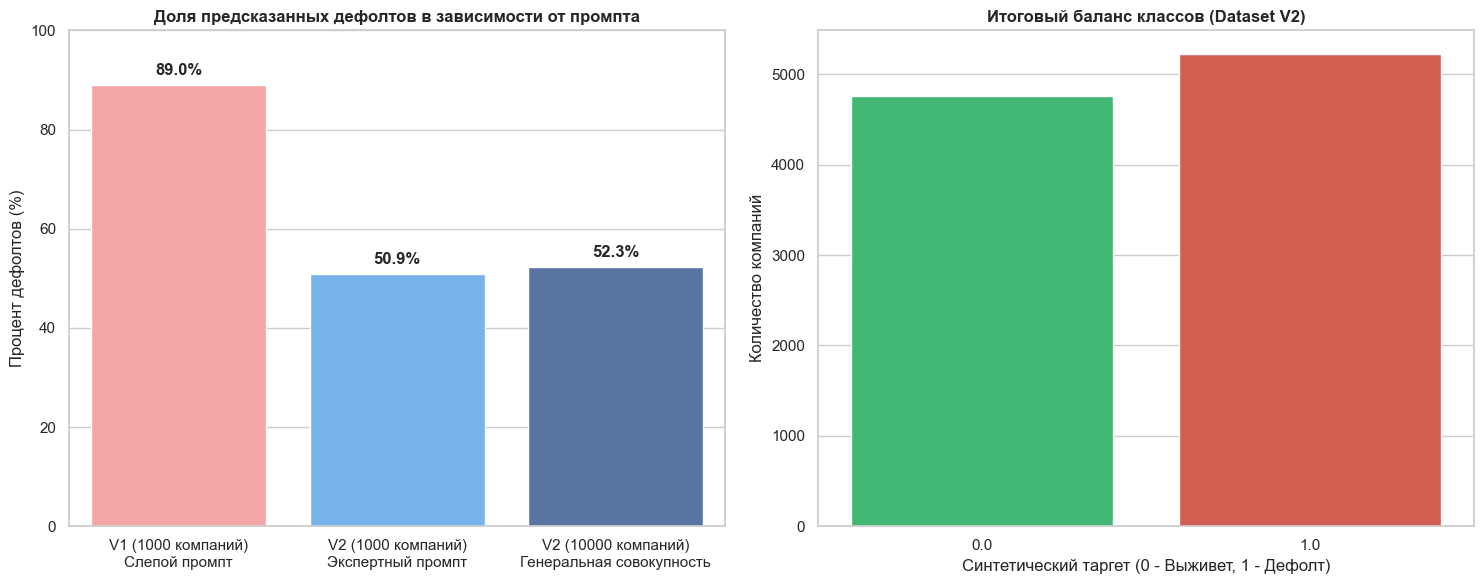

In [7]:
df_v1 = pd.read_csv(f"{save_path}synthetic_targets_re_1000.csv")
df_v2_full = pd.read_csv(f"{save_path}synthetic_targets_final_10000.csv")

df_v1 = df_v1.dropna(subset=['synthetic_default']).copy()
df_v2_full = df_v2_full.dropna(subset=['synthetic_default']).copy()

df_v2_1000 = df_v2_full[df_v2_full['inn'].isin(df_v1['inn'])].copy()

def_rate_v1 = df_v1['synthetic_default'].mean() * 100
def_rate_v2_1k = df_v2_1000['synthetic_default'].mean() * 100
def_rate_v2_10k = df_v2_full['synthetic_default'].mean() * 100

print(f"V1 (Слепая генерация, 1000 шт.): Дефолтов {def_rate_v1:.1f}%")
print(f"V2 (Умный промпт, 1000 шт.):    Дефолтов {def_rate_v2_1k:.1f}%")
print(f"V2 (Умный промпт, 10000 шт.):   Дефолтов {def_rate_v2_10k:.1f}%")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rates = [def_rate_v1, def_rate_v2_1k, def_rate_v2_10k]
labels = ['V1 (1000 компаний)\nСлепой промпт', 'V2 (1000 компаний)\nЭкспертный промпт', 'V2 (10000 компаний)\nГенеральная совокупность']
colors = ['#ff9999', '#66b3ff', '#4c72b0']

sns.barplot(x=labels, y=rates, palette=colors, ax=axes[0])
axes[0].set_title('Доля предсказанных дефолтов в зависимости от промпта', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Процент дефолтов (%)')
axes[0].set_ylim(0, 100)

for i, v in enumerate(rates):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

sns.countplot(data=df_v2_full, x='synthetic_default', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Итоговый баланс классов (Dataset V2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Синтетический таргет (0 - Выживет, 1 - Дефолт)')
axes[1].set_ylabel('Количество компаний')

plt.tight_layout()
plt.show()

При сравнении разметок используем первую размеченную старым промптом 1000 компаний, разметку для тех же компаний новым промптом и полную разметку датасета. Видим резкое снижение доли дефолтов в новой разметке. Для анализа причин снова направляем файл с комментариями разметчика в Gemini и получаем подтверждение того, что модель избавилась от большинства галлюцинаций и значительно скорректировала рассуждения в сторону реализма.

Более того, получаем таргет, идеально сбалансированный для обучения модели (52% дефолтов). С точки зрения реальной банковской практики такой уровень дефолтности является экстремально высоким (в традиционных портфелях он редко превышает 2–5%). Однако для целей данного исследования подобный баланс классов является обоснованным:

Во-первых, сгенерированная целевая переменная отражает не свершившийся юридический дефолт, а структурную уязвимость бизнеса. LLM выступала в роли системы раннего предупреждения, размечая компании, не имеющие запаса прочности к макроэкономическим шокам (например, наличие отрицательного капитала).

Во-вторых, исходный набор данных формировался на основе открытых данных ФНС без предварительного банковского фильтра. В отличие от кредитного портфеля реального банка, куда попадают только заемщики, прошедшие жесткий прескоринг, генеральная совокупность датасета отражает естественное состояние открытого рынка, содержащего значительную долю стагнирующего микробизнеса.


### визуализация синтетического таргета на графе

In [9]:
edges_df = pd.read_csv(f'{save_path}graph_edges_new_10000.csv')
G = nx.from_pandas_edgelist(edges_df, source='source', target='target')
print(f"Узлов: {G.number_of_nodes()}, Связей: {G.number_of_edges()}")

Узлов: 10000, Связей: 42556


In [10]:
target_dict = dict(zip(df_v2_full['inn'].astype(str), df_v2_full['synthetic_default']))

VIS_SIZE = 1200

all_nodes = list(G.nodes())
random_nodes = random.sample(all_nodes, k=min(VIS_SIZE, len(all_nodes)))

G_sub = G.subgraph(random_nodes)

net_vis = Network(notebook=True, cdn_resources='remote', height="700px", width="100%", bgcolor="#222222", font_color="white")

for node_id in G_sub.nodes():
    item = data_ready[node_id] 
    profile = json.loads(item['json_for_llm'])
    
    inn = str(item['inn'])
    region = profile.get('region', 'Неизвестно')
    okved = profile.get('okved_section', 'Неизвестно')
    semantic_desc = item['text_for_embedding']
    
    target = target_dict.get(inn, None)
    
    if target == 1.0:
        node_color = "#e74c3c"
        status_text = "Дефолт (1)"
    elif target == 0.0:
        node_color = "#2ecc71"
        status_text = "Выживет (0)"
    else:
        node_color = "#95a5a6"
        status_text = "Неизвестно"
    
    hover_text = f"ИНН: {inn}\nПрогноз: {status_text}\nРегион: {region}\nОтрасль: {okved}\n\n{semantic_desc}"
    
    net_vis.add_node(int(node_id), label=str(inn), title=hover_text, color=node_color)

for u, v in G_sub.edges():
    net_vis.add_edge(int(u), int(v), color="#555555")

net_vis.barnes_hut(gravity=-5000, central_gravity=0.1, spring_length=200)
net_vis.show(f"{save_path}graph_color_{VIS_SIZE}.html")

./saved_1/graph_color_1200.html


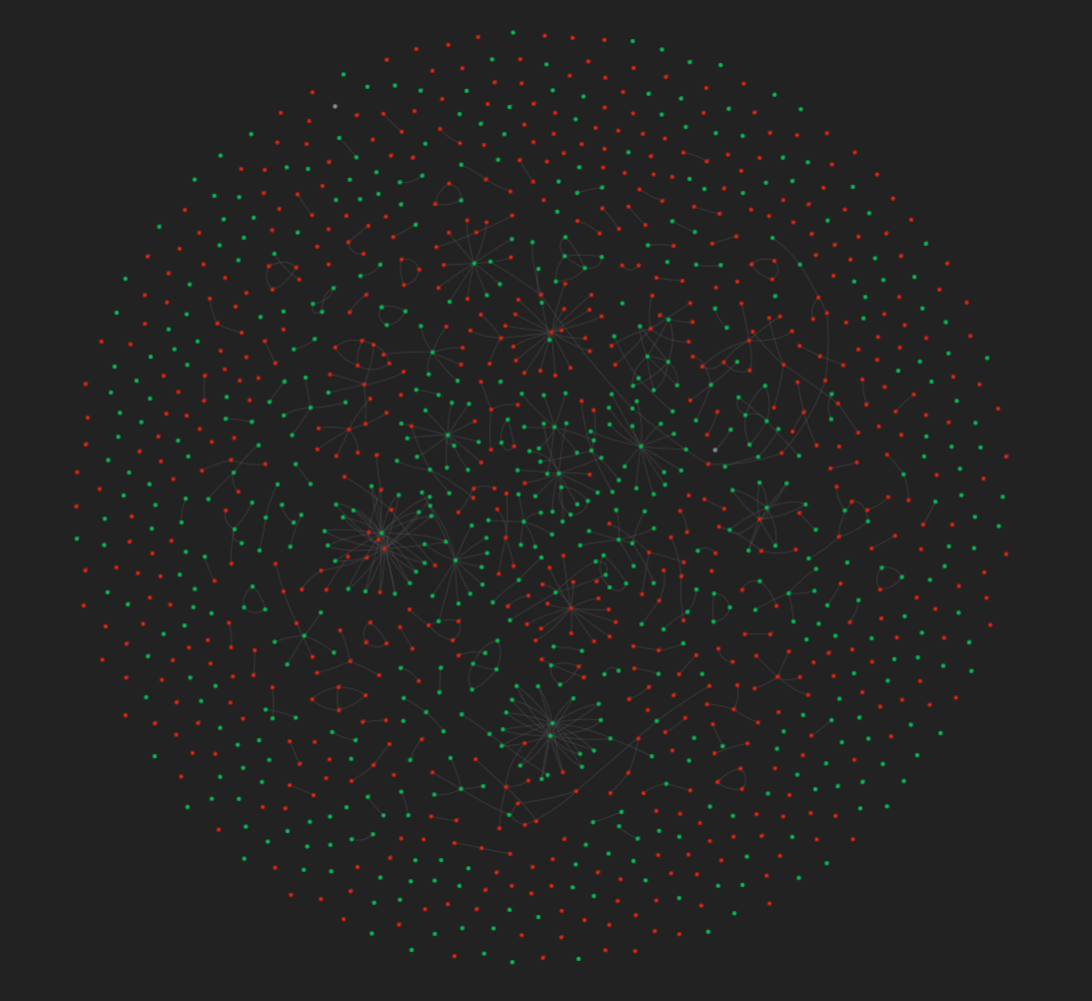

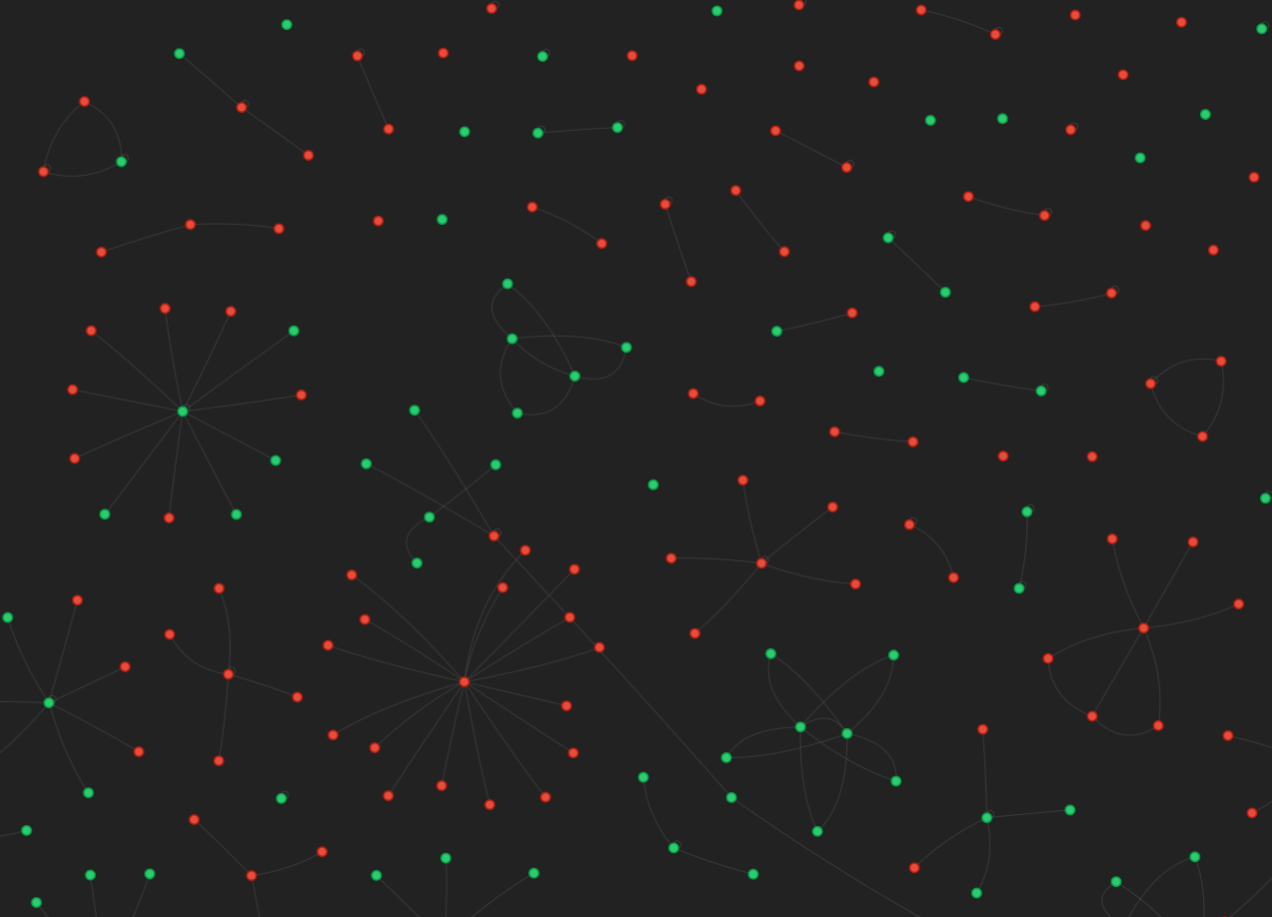

Добавили цветовое обозначение синтетического таргета при визуализации графа. Видим, что в основном внутри изолированных подграфов цвета совпали, однако есть и смешанные подграфы. (Стоит помнить, что это не полный датасет и в реальности подграфы больше).

### построение модели предсказания синтетического таргета

В качестве проверки (и для соблюдения требований к курсовой) строим графовую модель для предсказания нашего таргета. Выбираем сеть GraphSAGE. Выбор индуктивной архитектуры обусловлен тем, что исследуемый граф состоит из множества изолированных подграфов и кластеров. В отличие от спектральных методов (например, классической GCN), требующих глобальной связности сети, GraphSAGE формирует новые эмбеддинги узлов путем локального сэмплирования и агрегации признаков исключительно из ближайшей окрестности узла.

In [ ]:
embeddings = np.load(f'{save_path}embeddings_new_10000.npy')
x = torch.tensor(embeddings, dtype=torch.float32)
num_nodes = x.shape[0]

edges = list(G.edges())
src = [e[0] for e in edges]
dst = [e[1] for e in edges]

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_index = to_undirected(edge_index)

target_dict = dict(zip(df_v2_full['inn'].astype(str), df_v2_full['synthetic_default']))

y_list = []
valid_nodes_mask = []

for node_id in range(num_nodes):
    item = data_ready[node_id] 
    inn = str(item['inn'])
    target = target_dict.get(inn, None)
    
    if target == 1.0 or target == 0.0:
        y_list.append(target)
        valid_nodes_mask.append(True)
    else:
        y_list.append(0.0) # Заглушка для неизвестных (loss их проигнорирует)
        valid_nodes_mask.append(False)

y = torch.tensor(y_list, dtype=torch.float32)

valid_indices = torch.tensor(valid_nodes_mask).nonzero(as_tuple=True)[0]
valid_indices = valid_indices[torch.randperm(len(valid_indices))] 

num_valid = len(valid_indices)
train_size = int(num_valid * 0.7)
val_size = int(num_valid * 0.15)

train_idx = valid_indices[:train_size]
val_idx = valid_indices[train_size:train_size + val_size]
test_idx = valid_indices[train_size + val_size:]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

print(f"Граф собран. Вершин: {data.num_nodes}, Ребер: {data.num_edges//2}, Размерность фичей: {data.num_node_features}")

Граф собран. Вершин: 10000, Ребер: 41535, Размерность фичей: 1024


In [17]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
class BinaryGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(BinaryGraphSAGE, self).__init__()
        # Для графов по косинусной близости часто лучше работает aggr='max'
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='max')
        self.conv2 = SAGEConv(hidden_channels, 1, aggr='max')

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

model = BinaryGraphSAGE(in_channels=data.num_node_features, hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.BCEWithLogitsLoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index).squeeze()
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x, data.edge_index).squeeze()
    
    probs = torch.sigmoid(out[mask]).cpu().numpy()
    preds = (probs > 0.5).astype(float)
    y_true = data.y[mask].cpu().numpy()
    
    acc = accuracy_score(y_true, preds)
    roc_auc = roc_auc_score(y_true, probs) 
    return acc, roc_auc

for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        val_acc, val_auc = test(data.val_mask)
        print(f'Эпоха: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Val ROC-AUC: {val_auc:.4f}')

test_acc, test_auc = test(data.test_mask)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test ROC-AUC: {test_auc:.4f}')

Эпоха: 010, Loss: 0.3877, Val Acc: 0.8489, Val ROC-AUC: 0.9233
Эпоха: 020, Loss: 0.3173, Val Acc: 0.8483, Val ROC-AUC: 0.9373
Эпоха: 030, Loss: 0.2963, Val Acc: 0.8596, Val ROC-AUC: 0.9440
Эпоха: 040, Loss: 0.2942, Val Acc: 0.8650, Val ROC-AUC: 0.9459
Эпоха: 050, Loss: 0.2897, Val Acc: 0.8610, Val ROC-AUC: 0.9461
Эпоха: 060, Loss: 0.3026, Val Acc: 0.8603, Val ROC-AUC: 0.9473
Эпоха: 070, Loss: 0.2904, Val Acc: 0.8610, Val ROC-AUC: 0.9475
Эпоха: 080, Loss: 0.2805, Val Acc: 0.8603, Val ROC-AUC: 0.9485
Эпоха: 090, Loss: 0.2770, Val Acc: 0.8670, Val ROC-AUC: 0.9486
Эпоха: 100, Loss: 0.2814, Val Acc: 0.8583, Val ROC-AUC: 0.9498
Test Accuracy: 0.8618
Test ROC-AUC: 0.9424


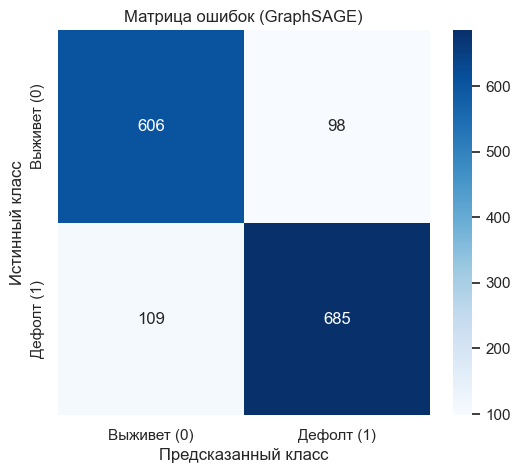

              precision    recall  f1-score   support

     Выживет       0.85      0.86      0.85       704
      Дефолт       0.87      0.86      0.87       794

    accuracy                           0.86      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.86      0.86      0.86      1498



In [ ]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index).squeeze()
    probs = torch.sigmoid(out[data.test_mask]).cpu().numpy()
    preds = (probs > 0.5).astype(int)
    y_true = data.y[data.test_mask].cpu().numpy()

cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Выживет (0)', 'Дефолт (1)'], 
            yticklabels=['Выживет (0)', 'Дефолт (1)'])
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.title('Матрица ошибок (GraphSAGE)')
plt.show()

print(classification_report(y_true, preds, target_names=['Выживет', 'Дефолт']))

Выводим матрицу ошибок модели и метрики. Видим хорошие результаты. Для сравнения и проверки необходимости использования сложной модели проведем обучение простой модели логистической регресии.

Видим, что логистическая регрессия показывает схожие метрики с графовой нейросетью. На самом деле, это говорит о линейной разделимости классов синтетического таргета, значит LLM уловила экономическую специфику при разметке, а эмбеддинги оказались качественными.

In [ ]:
X_train = data.x[data.train_mask].cpu().numpy()
y_train = data.y[data.train_mask].cpu().numpy()
X_test = data.x[data.test_mask].cpu().numpy()
y_test = data.y[data.test_mask].cpu().numpy()

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")

Logistic Regression Accuracy: 0.8518
Logistic Regression ROC-AUC: 0.9425


Используем GraphSAGE и определим вероятности для неразмеченных компаний.

In [ ]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index).squeeze()
    all_probs = torch.sigmoid(out).cpu().numpy()

unknown_indices = (~torch.tensor(valid_nodes_mask)).nonzero(as_tuple=True)[0]

print("Определение вероятности дефолта для пропусков:")
results = []
for idx in unknown_indices:
    idx = idx.item()
    prob = all_probs[idx]
    inn = str(data_ready[idx]['inn'])
    results.append((inn, prob))

results.sort(key=lambda x: x[1], reverse=True)

for inn, prob in results:
    print(f"ИНН {inn} - Вероятность дефолта: {prob:.1%}")

Определение вероятности дефолта для пропусков:
ИНН 1627009614.0 - Вероятность дефолта: 99.6%
ИНН 7726284130.0 - Вероятность дефолта: 99.5%
ИНН 7720432705.0 - Вероятность дефолта: 99.4%
ИНН 7736280705.0 - Вероятность дефолта: 99.3%
ИНН 7717613892.0 - Вероятность дефолта: 98.9%
ИНН 7734690921.0 - Вероятность дефолта: 98.9%
ИНН 6633013336.0 - Вероятность дефолта: 98.7%
ИНН 7723711908.0 - Вероятность дефолта: 98.4%
ИНН 2311242091.0 - Вероятность дефолта: 98.3%
ИНН 9710074941.0 - Вероятность дефолта: 96.6%
ИНН 7813290228.0 - Вероятность дефолта: 86.9%
ИНН 6685145686.0 - Вероятность дефолта: 54.0%
ИНН 7807191155.0 - Вероятность дефолта: 51.2%
ИНН 7724445254.0 - Вероятность дефолта: 47.7%
ИНН 7708812860.0 - Вероятность дефолта: 45.0%
ИНН 6670245568.0 - Вероятность дефолта: 35.8%
ИНН 7724307039.0 - Вероятность дефолта: 34.5%
ИНН 7731136440.0 - Вероятность дефолта: 26.5%
ИНН 7717713488.0 - Вероятность дефолта: 17.5%
ИНН 7714752979.0 - Вероятность дефолта: 13.3%
ИНН 7813380023.0 - Вероятность де

## выводы по работе

В ходе выполнения курсовой работы был разработан и протестирован метод генерации синтетических графовых датасетов для кредитного скоринга с помощью больших языковых моделей (LLM). Этот подход позволяет обойти проблему закрытости банковских данных и создавать качественные наборы для обучения ML-алгоритмов на базе открытой отчетности.

По итогам исследования можно сделать следующие выводы:

Подготовка данных и эмбеддинги. Был собран и агрегирован набор данных на 10 000 компаний за период 2017–2024 годов. Для того чтобы нейросеть лучше понимала финансовую специфику, числовые данные (выручка, долги, капитал) были переведены в текстовые описания. Полученные на их основе эмбеддинги позволили оценивать компании не по формальным признакам, а по реальному экономическому смыслу.

Построение графа. Использование алгоритма k-ближайших соседей вместо глобального порога сходства позволило построить качественный экономический граф без изолированных вершин. Структурный анализ показал, что алгоритм успешно сгруппировал предприятия в логичные кластеры (например, выделив крупный сегмент микробизнеса с признаками стагнации).

Разметка с помощью LLM. Использование локальной языковой модели (Qwen3-8B) для оценки риска дефолта доказало свою эффективность. Анализ первых результатов позволил выявить ошибки логики модели (галлюцинации). После корректировки промпта и добавления в него реальных правил банковского риск-менеджмента, генерация стабилизировалась. Итоговый датасет получил сбалансированную разметку таргета (52.3% дефолтов) и набор текстовых бизнес-гипотез для каждой компании.

Проверка качества датасета. Для валидации полученных данных была обучена графовая нейросеть (GraphSAGE). Высокие показатели качества на тестовой выборке (ROC-AUC 0.94) подтверждают, что сгенерированная LLM разметка не является случайной. Данные содержат четкую экономическую логику, которую алгоритмы машинного обучения могут успешно распознать и усвоить.

В результате получен рабочий программный конвейер. Сгенерированные таким образом датасеты и бизнес-гипотезы могут применяться для тестирования банковских скоринговых систем без риска раскрытия реальной коммерческой тайны.

В качестве направления для дальнейшей работы можно рассматривать подключение LLM к внешним базам знаний (подход RAG). Это позволит модели при оценке дефолта опираться на актуальные новости, налоговое законодательство и свежую макроэкономическую статистику.
